# PC Prices Analysis Project

<u> Dependencies: </u>
<br>Please Use PIP to install the following packages

<b> pip install pcpartpicker <br>
pip install nest_asyncio </b>

In [3]:
# Import packages

# General Packages
import pandas as pd
import numpy as np
import os


#For the pcpartpicker API
from pcpartpicker import API
import pcpartpicker
import nest_asyncio

# Grpahs
import seaborn as sns
import matplotlib.pyplot as plt

In [4]:
# Functions
def header(txt):
    '''Takes a string of text (txt) and prints it to the screen underlined'''
    print("\033[4m"+str(txt)+"\033[0m")

def get_shape(df):
    # get the number of columns and rows in the datasest:
    print("Row Count: ", df.shape[0])
    print("Col Count: ", df.shape[1])

# 1. Business Understanding

## Summary
- A shortage of GPUs has resulted in elevated prices of high-end PCs. 
- The majority of literature focuses on prices of GPUs, limited acknowledgement of other components such as screen resolution, CPU, etc in price matrix.
- Limited evaluation of manufacturer brand on price (e.g. Nvidia vs INTEL for GPU, Mac vs Windows for Operating System).  
- Goal: Develop a reliable model for assessing the price of PCs by identifying features that have the most significant impact on price.



# 2 . Data Understanding
## Laptop Prices Dataset
The Laptop prices were initally inspected in Excel to view the features in the dataset and access the nature of each feature, as well as comparing the prices of laptops in the dataset to similar models avaialble on google to test if the dataset was real.

## pcpartpicker Data

This section will provide a brief overview of the PCPartspicker API.

In [8]:
# Apply Nest Asyncio 
nest_asyncio.apply()

# Note: without this piece of code, the API program will fail, as it detects that there is another program running on this computer (Juypter)
# In order to prevent throwing up an error, the line of code above enables the api to believe there isn't any other program running but it

# Pull the entire database of parts
api = pcpartpicker.API()
allData = api.retrieve_all()

In [9]:
#Inspect the entire dataset (WARNING, THIS THING IS MASSIVE)
allData

{'speakers': [Speakers(brand='Altec Lansing', model='BX1520', channel_configuration=2.0, wattage=6, frequency_response=None, color=None, price=<Money: 0.00 USD>),
  Speakers(brand='Altec Lansing', model='BX1521', channel_configuration=2.1, wattage=0, frequency_response=None, color=None, price=<Money: 0.00 USD>),
  Speakers(brand='Altec Lansing', model='VS3030', channel_configuration=2.0, wattage=0, frequency_response=None, color=None, price=<Money: 0.00 USD>),
  Speakers(brand='Altec Lansing', model='VS4621', channel_configuration=2.1, wattage=28, frequency_response=FrequencyResponse(min=45.0, max=18000.0, default=None), color='Black', price=<Money: 0.00 USD>),
  Speakers(brand='AmazonBasics', model='U213', channel_configuration=2.0, wattage=2, frequency_response=FrequencyResponse(min=103.0, max=20000.0, default=None), color='Black', price=<Money: 17.98 USD>),
  Speakers(brand='AmazonBasics', model='V216US', channel_configuration=2.0, wattage=4, frequency_response=FrequencyResponse(min

In [10]:
# The previous cell's output demonstrates the scope of the dictionary, but also all the features are classes depending on the computer part in question
# Return only the keys of the dictionary (i.e. what type of parts are in the dataset)
header("List of Parts")
for i in allData.keys():
    print(i)

List of Parts
speakers
optical-drive
cpu-cooler
mouse
ups
wired-network-card
case
thermal-paste
memory
case-fan
monitor
motherboard
fan-controller
keyboard
video-card
external-hard-drive
cpu
internal-hard-drive
headphones
sound-card
power-supply
wireless-network-card


# 3. Importing

## Laptop Prices Dataset

This next section covers importing the laptop dataset from a CSV to a Pandas Dataframe.

In [13]:
# Get Laptop prices file

df = pd.read_csv('laptop_prices.csv')
# Note: Despite being an excel file, the read_excel file function did not work with the data set, as the file is saved in an excel enabled csv

In [14]:
#Inspect first 8 rows
df.head(8)

,Company,Product,TypeName,Inches,Ram,OS,Weight,Price_euros,Screen,ScreenW,...,RetinaDisplay,CPU_company,CPU_freq,CPU_model,PrimaryStorage,SecondaryStorage,PrimaryStorageType,SecondaryStorageType,GPU_company,GPU_model
0,Apple,MacBook Pro,Ultrabook,13.3,8,macOS,1.37,1339.69,Standard,2560,...,Yes,Intel,2.3,Core i5,128,0,SSD,No,Intel,Iris Plus Graphics 640
1,Apple,Macbook Air,Ultrabook,13.3,8,macOS,1.34,898.94,Standard,1440,...,No,Intel,1.8,Core i5,128,0,Flash Storage,No,Intel,HD Graphics 6000
2,HP,250 G6,Notebook,15.6,8,No OS,1.86,575.00,Full HD,1920,...,No,Intel,2.5,Core i5 7200U,256,0,SSD,No,Intel,HD Graphics 620
3,Apple,MacBook Pro,Ultrabook,15.4,16,macOS,1.83,2537.45,Standard,2880,...,Yes,Intel,2.7,Core i7,512,0,SSD,No,AMD,Radeon Pro 455
4,Apple,MacBook Pro,Ultrabook,13.3,8,macOS,1.37,1803.60,Standard,2560,...,Yes,Intel,3.1,Core i5,256,0,SSD,No,Intel,Iris Plus Graphics 650
5,Acer,Aspire 3,Notebook,15.6,4,Windows 10,2.10,400.00,Standard,1366,...,No,AMD,3.0,A9-Series 9420,500,0,HDD,No,AMD,Radeon R5
6,Apple,MacBook Pro,Ultrabook,15.4,16,Mac OS X,2.04,2139.97,Standard,2880,...,Yes,Intel,2.2,Core i7,256,0,Flash Storage,No,Intel,Iris Pro Graphics
7,Apple,Macbook Air,Ultrabook,13.3,8,macOS,1.34,1158.70,Standard,1440,...,No,Intel,1.8,Core i5,256,0,Flash Storage,No,Intel,HD Graphics 6000


In [15]:
# Get shape of dataset
#print("Row Count: ", df.shape[0])
#print("Col Count: ", df.shape[1])
get_shape(df)

Row Count:  1275
Col Count:  23


### PCPartsPicker Data

This next section demonstrates how to convert the PCPartsPicker into multipul pandas dataframes. The first section will cover the CPU dataset, addressing the dq issues that prevented joining the CPU dataset, and concluding with the creation of the mouse, keyboard, and headphones dataset.

In [18]:
# Inspect the CPU data
cpuData = allData['cpu']
cpuData

[CPU(brand='AMD', model='2650', cores=2, base_clock=ClockSpeed(cycles=1450000000), boost_clock=None, tdp=25, integrated_graphics='Radeon HD 8240', multithreading=False, price=<Money: 59.61 USD>),
 CPU(brand='AMD', model='3850', cores=4, base_clock=ClockSpeed(cycles=1300000000), boost_clock=None, tdp=25, integrated_graphics='Radeon HD 8280', multithreading=False, price=<Money: 79.59 USD>),
 CPU(brand='AMD', model='5150', cores=4, base_clock=ClockSpeed(cycles=1600000000), boost_clock=None, tdp=25, integrated_graphics='Radeon HD 8400', multithreading=False, price=<Money: 0.00 USD>),
 CPU(brand='AMD', model='5350', cores=4, base_clock=ClockSpeed(cycles=2049999999), boost_clock=None, tdp=25, integrated_graphics='Radeon HD 8400', multithreading=False, price=<Money: 104.94 USD>),
 CPU(brand='AMD', model='5350', cores=4, base_clock=ClockSpeed(cycles=2049999999), boost_clock=None, tdp=25, integrated_graphics='Radeon HD 8400', multithreading=False, price=<Money: 0.00 USD>),
 CPU(brand='AMD', mod

In [19]:
# Inspect the brand, model and price attributes
for cpu in cpuData:
    print(cpu.brand,"-", cpu.model, "-", cpu.price)

AMD - 2650 - US$59.61
AMD - 3850 - US$79.59
AMD - 5150 - US$0.00
AMD - 5350 - US$104.94
AMD - 5350 - US$0.00
AMD - A10-5700 - US$0.00
AMD - A10-5800K - US$0.00
AMD - A10-6700 - US$0.00
AMD - A10-6700T - US$0.00
AMD - A10-6790B - US$0.00
AMD - A10-6790K - US$0.00
AMD - A10-6800B - US$0.00
AMD - A10-6800K - US$0.00
AMD - A10-7700K - US$547.80
AMD - A10-7700K - US$0.00
AMD - A10-7800 - US$0.00
AMD - A10-7850K - US$273.83
AMD - A10-7850K - US$0.00
AMD - A10-7860k - US$0.00
AMD - A10-7870K - US$0.00
AMD - A10-7890K - US$0.00
AMD - A10-9700 - US$242.87
AMD - A10-9700E - US$292.98
AMD - A12-9800 - US$0.00
AMD - A12-9800E - US$177.45
AMD - A4-3300 - US$0.00
AMD - A4-3300 - US$85.00
AMD - A4-3400 - US$149.94
AMD - A4-3400 - US$0.00
AMD - A4-3420 - US$0.00
AMD - A4-3450 - US$0.00
AMD - A4-4000 - US$0.00
AMD - A4-4000 - US$139.84
AMD - A4-4020 - US$0.00
AMD - A4-5300 - US$0.00
AMD - A4-5300 - US$93.74
AMD - A4-6300 - US$0.00
AMD - A4-6300B - US$0.00
AMD - A4-6320 - US$0.00
AMD - A4-7300 - US$135.

In [20]:
#Convert the cpu dataset from a series of objects in Python (CPU class) to a dictionary, and then from a dictionary to a Dataframe

# Inital Dictionary
cpuDataDictionary = {
    "brand" :                    [cpu.brand for cpu in cpuData],
    "model" :                    [cpu.model for cpu in cpuData],
    "cores" :                    [cpu.cores for cpu in cpuData],
    "base_clock_speed":          [cpu.base_clock.cycles for cpu in cpuData],
    "tdp" :                      [cpu.tdp for cpu in cpuData],
    "integrated_graphics" :      [cpu.integrated_graphics for cpu in cpuData],
    "multithreading" :           [cpu.multithreading for cpu in cpuData],
    "price" :                    [cpu.price for cpu in cpuData]
}

#Dictionary to dataframe
dfCPU = pd.DataFrame(cpuDataDictionary)
dfCPU

,brand,model,cores,base_clock_speed,tdp,integrated_graphics,multithreading,price
0,AMD,2650,2,1450000000,25,Radeon HD 8240,False,US$59.61
1,AMD,3850,4,1300000000,25,Radeon HD 8280,False,US$79.59
2,AMD,5150,4,1600000000,25,Radeon HD 8400,False,US$0.00
3,AMD,5350,4,2049999999,25,Radeon HD 8400,False,US$104.94
4,AMD,5350,4,2049999999,25,Radeon HD 8400,False,US$0.00
...,...,...,...,...,...,...,...,...
1066,Intel,Xeon E5-2698 V4,20,2200000000,135,None,True,US$0.00
1067,Intel,Xeon E5-2699 V3,18,2300000000,145,None,True,"US$3,089.95"
1068,Intel,Xeon E5-2699 V4,22,2200000000,145,None,True,"US$1,519.93"
1069,Intel,Xeon E5-4620,8,2200000000,95,None,True,"US$1,599.99"


In [21]:
# Check the presence of GPUs on the dataset
dfCPU.model.unique

<bound method Series.unique of 0                  2650
1                  3850
2                  5150
3                  5350
4                  5350
             ...       
1066    Xeon E5-2698 V4
1067    Xeon E5-2699 V3
1068    Xeon E5-2699 V4
1069       Xeon E5-4620
1070       Xeon E5-4650
Name: model, Length: 1071, dtype: object>

In [22]:
# Inspect the cpu model columns of both tables to see there is crossover
df[df["CPU_model"].isin(dfCPU["model"])]

,Company,Product,TypeName,Inches,Ram,OS,Weight,Price_euros,Screen,ScreenW,...,RetinaDisplay,CPU_company,CPU_freq,CPU_model,PrimaryStorage,SecondaryStorage,PrimaryStorageType,SecondaryStorageType,GPU_company,GPU_model


In [23]:
# Inspecting the values on both datasets
# Note: This part was run manually to confirm what was covered in the cell above

In [24]:
df["CPU_model"][df["CPU_model"].str.contains('Core i7', case=False, na=False)]

3             Core i7
6             Core i7
8       Core i7 8550U
12            Core i7
16      Core i7 7500U
            ...      
1267    Core i7 7500U
1269    Core i7 6500U
1270    Core i7 6500U
1271    Core i7 6500U
1273    Core i7 6500U
Name: CPU_model, Length: 515, dtype: object

In [25]:
dfCPU['model'][dfCPU['model'].str.contains('Core i7', case=False, na=False)]

633                   Core i7-10700
634                  Core i7-10700F
635                  Core i7-10700K
636                 Core i7-10700KF
637                    Core i7-2600
                   ...             
734                     Core i7-980
735                   Core i7-9800X
736                   Core i7-9800X
737    Core i7-980X Extreme Edition
738    Core i7-990X Extreme Edition
Name: model, Length: 106, dtype: object

### Conclusion
It is not possible to join the two tables as there is no common column to join them. The logic used to get the price data for CPUs will be used for common pc complimentary goods, such as headphones, mouses and keyboards

In [27]:
#Headphones
#Convert the dataset from a series of objects in Python (CPU class) to a dictionary, and then from a dictionary to a Dataframe
hpData = allData['headphones']

# Inital Dictionary
headphonesDataDictionary = {
    "brand" :              [obj.brand for obj in hpData],
    "model" :              [obj.model for obj in hpData],
    "form_factor" :        [obj.form_factor for obj in hpData],
    "frequency_response":  [obj.frequency_response for obj in hpData],
    "has_microphone" :     [obj.has_microphone for obj in hpData],
    "is_wireless" :        [obj.is_wireless for obj in hpData],
    "color" :              [obj.color for obj in hpData],
    "price" :              [obj.price for obj in hpData]
}

#Dictionary to dataframe
dfHeadphones = pd.DataFrame(headphonesDataDictionary)
dfHeadphones

,brand,model,form_factor,frequency_response,has_microphone,is_wireless,color,price
0,1MORE,EHD9001TA,In Ear,None,False,True,Black / Red,US$0.00
1,1MORE,Quad Driver,In Ear,"FrequencyResponse(min=20.0, max=40000.0, defau...",True,False,Black / Red,US$124.23
2,1MORE,Triple Driver (Black/Gold),In Ear,"FrequencyResponse(min=20.0, max=40000.0, defau...",True,False,Black / Gold,US$79.98
3,1MORE,Triple Driver (Silver),In Ear,"FrequencyResponse(min=20.0, max=40000.0, defau...",True,False,Silver,US$67.98
4,1MORE,Triple Driver Lightning (Silver),In Ear,"FrequencyResponse(min=20.0, max=40000.0, defau...",True,False,Silver,US$84.95
...,...,...,...,...,...,...,...,...
2412,Zalman,ZM-HPS10BT,Supra-aural,"FrequencyResponse(min=100.0, max=20000.0, defa...",True,False,Black,US$0.00
2413,Zalman,ZM-RS6F,Circumaural,"FrequencyResponse(min=50.0, max=20000.0, defau...",False,False,Black / Silver,US$0.00
2414,Zalman,ZM-RS6F,Circumaural,"FrequencyResponse(min=50.0, max=20000.0, defau...",False,False,Black,US$0.00
2415,Ziotek,190 0282,Supra-aural,None,False,False,Black,US$0.00


In [28]:
get_shape(dfHeadphones)

Row Count:  2417
Col Count:  8


In [29]:
#Mouses
#Convert the dataset from a series of objects in Python (CPU class) to a dictionary, and then from a dictionary to a Dataframe
mouseData = allData['mouse']

# Inital Dictionary
mouseDataDictionary = {
    "brand" :              [obj.brand for obj in mouseData],
    "model" :              [obj.model for obj in mouseData],
    "tracking" :           [obj.tracking for obj in mouseData],
    "connection":          [obj.connection for obj in mouseData],
    "max_dpi" :            [obj.max_dpi for obj in mouseData],
    "hand_orientation" :   [obj.hand_orientation for obj in mouseData],
    "color" :              [obj.color for obj in mouseData],
    "price" :              [obj.price for obj in mouseData]
}

#Dictionary to dataframe
dfMouse = pd.DataFrame(mouseDataDictionary)
dfMouse

,brand,model,tracking,connection,max_dpi,hand_orientation,color,price
0,3M,EM500GPL,Optical,Wired,NaN,Right,Black / Silver,US$56.00
1,3M,EM500GPS,Optical,Wired,NaN,Right,Black,US$99.99
2,3M,EM550GPL,Optical,Wireless,NaN,Right,Black,US$78.58
3,3M,EM550GPS,Optical,Wireless,NaN,Right,Black,US$78.69
4,A4Tech,AL90,Laser,Wired,NaN,Right,Black,US$0.00
...,...,...,...,...,...,...,...,...
2011,Zowie,S2,Optical,Wired,3200.0,Right,Black,US$69.99
2012,Zowie,ZA11,Optical,Wired,3200.0,Both,Black,US$0.00
2013,Zowie,ZA12,Optical,Wired,3200.0,Both,Black,US$59.99
2014,Zowie,ZA13,Optical,Wired,3200.0,Both,Black,US$87.57


In [30]:
get_shape(dfMouse)

Row Count:  2016
Col Count:  8


In [31]:
#Keyboards
#Convert the dataset from a series of objects in Python (CPU class) to a dictionary, and then from a dictionary to a Dataframe
KeyboardData = allData['keyboard']

# Inital Dictionary
KeyboardDataDictionary = {
    "brand" :        [obj.brand for obj in KeyboardData],
    "model" :        [obj.model for obj in KeyboardData],
    "style" :        [obj.style for obj in KeyboardData],
    "switches":      [obj.switches for obj in KeyboardData],
    "backlight" :    [obj.backlight for obj in KeyboardData],
    "tenkeyless" :   [obj.tenkeyless for obj in KeyboardData],
    "connection" :   [obj.connection for obj in KeyboardData],
    "color" :        [obj.color for obj in KeyboardData],
    "price" :        [obj.price for obj in KeyboardData]
}

#Dictionary to dataframe
dfKeyboard = pd.DataFrame(KeyboardDataDictionary)
dfKeyboard

,brand,model,style,switches,backlight,tenkeyless,connection,color,price
0,1STPLAYER,FIRE ROSE MK3,Gaming,Outemu Blue,RGB,False,Wired,White,US$0.00
1,A4Tech,3100N,Standard,None,None,False,Wireless,Black,US$0.00
2,A4Tech,7300N,Ergonomic,None,None,True,Wireless,Gray / Black,US$29.99
3,A4Tech,7700N,Mini,None,None,True,Wireless,Silver / Black,US$0.00
4,A4Tech,9300F,Ergonomic,None,None,False,Wireless,Black,US$0.00
...,...,...,...,...,...,...,...,...,...
2337,matias,Mini Quiet Pro for PC,Mini,ALPS White,None,True,Wired,Black,US$119.95
2338,matias,Quiet Pro Keyboard for Mac,Standard,ALPS White,None,False,Wired,Black / Silver,US$0.00
2339,matias,Quiet Pro Keyboard for PC,Standard,ALPS White,None,False,Wired,Black,US$0.00
2340,matias,Tactile Pro for Mac,Standard,ALPS Clicky Simplified White,None,False,Wired,White,US$139.95


In [32]:
get_shape(dfKeyboard)

Row Count:  2342
Col Count:  9


# 4. Data Preparation

The following section will document the process of analysising the data for data quality issues, assess the best strategy for resolving these issues and implementing a resolution to the DQ issues, as well as assessing the prospect of creating new features entirly.

In [34]:
def check_duplicates(df):
    #return the number of duplicate rows in the dataset
    dfDuplicateRows = df.duplicated().sum()
    return dfDuplicateRows

def adjust_price(feature):
    #adjust the price columns to move from the moneyed class to the float64
    return feature.apply(lambda x: x.amount).astype(float)

def adjust_price(feature):
    #adjust the price columns to move from the moneyed class to the float64
    return feature.apply(lambda x: x.amount).astype(float)

def dollar_to_euro(amount):
    #convert dollar amount to euors using exchange rates from 19/11/24
    dollarToEuroRate = 0.9438
    return amount * dollarToEuroRate

def correct_price_column(df):
    #convert the price column in the PCPartsPicker dataset to use floating point instead of the Moneyed Class and change from dollar amounts to euro
    df["price"] = adjust_price(df["price"])
    df["price"] = df["price"].apply(lambda x: dollar_to_euro(x))

def inspect_data(df):
    #print out the values in each column
    #inital inspection of dataset
    for c in df.columns.to_list():
        print(df[c].value_counts(),"\n" )

def inspect_missing_values(df):
    #return number of missing values in each column:
    missing = []
    missing.append(df.isna().sum())
    return missing

def inspect_missing_values_percentage(df):
    # Check what % missing
    missing = list(inspect_missing_values(df))
    for i in missing:
        missing = (i/df.shape[0])*100
    return missing

def get_categorical_details(dfCategorical):
    #return summary statistics on a series of categorial features
    #get count and cardinality
    dfCategoricalSummary = dfCategorical.describe().T


    # Get the mode of each categorical feature feature
    category_modes = pd.DataFrame(index=dfCategoricalSummary.index,columns=['mode','freq_mode','freq_mode(%)','2ndmode','freq_2ndmode','freq_2ndmode(%)'])

    for i in dfCategorical.columns.to_list():
        #get mode data
        category_modes.loc[i, 'mode'] = dfCategorical[i].value_counts().keys()[0]
        category_modes.loc[i, 'freq_mode'] = dfCategorical[i].value_counts().loc[category_modes.loc[i, 'mode']]
        category_modes.loc[i, 'freq_mode(%)'] = dfCategorical[i].value_counts(normalize=True).loc[category_modes.loc[i, 'mode']]
    
        #get secondary mode data
        category_modes.loc[i, '2ndmode'] = dfCategorical[i].value_counts().keys()[1]
        category_modes.loc[i, 'freq_2ndmode'] = dfCategorical[i].value_counts().loc[category_modes.loc[i, '2ndmode']]
        category_modes.loc[i, 'freq_2ndmode(%)'] = dfCategorical[i].value_counts(normalize=True).loc[category_modes.loc[i, '2ndmode']]


    #merge two datasets together
    dfCategoricalSummary = pd.concat([dfCategoricalSummary[["count","unique"]], category_modes], axis = 1)
    return dfCategoricalSummary

def get_continuous_details(dfContinuous):
    #return summary statistics on the numeric data features
    #get main summary statistics
    dfContinuousSummary = dfContinuous.describe().T

    #Get Cardinality
    dfContinuousCardinality = pd.DataFrame({"Unique": dfContinuous.nunique()})

    #merge data into single dataframe
    dfContinuousSummary = pd.concat([dfContinuousSummary, dfContinuousCardinality], axis = 1)

    return dfContinuousSummary

def split_data(df, removeNulls=False):
    #split the data into numeric and categorical
        
    #splits the columns between categorial and numeric data:
    dfContinuousColumns = df.select_dtypes(['float64','int64']).columns
    dfCategoricalColumns = df.select_dtypes(['object','bool']).columns

    #returns the two datasets in a dictionary
    results = { "numeric": df[dfContinuousColumns],
                "categorical": df[dfCategoricalColumns]
              }

    return results

def check_negative_values(df, column):
    result = df[df[column] < 0]
    return result

## Laptop Prices Dataset

In [36]:
#Get Data Types
header("Data Types: Main Dataset")
df.dtypes

Data Types: Main Dataset


Company                  object
Product                  object
TypeName                 object
Inches                  float64
Ram                       int64
OS                       object
Weight                  float64
Price_euros             float64
Screen                   object
ScreenW                   int64
ScreenH                   int64
Touchscreen              object
IPSpanel                 object
RetinaDisplay            object
CPU_company              object
CPU_freq                float64
CPU_model                object
PrimaryStorage            int64
SecondaryStorage          int64
PrimaryStorageType       object
SecondaryStorageType     object
GPU_company              object
GPU_model                object
dtype: object

In [37]:
#Check for Duplicates
dfDuplicateRows = check_duplicates(df)
print("Number of Duplicate Rows: {}".format(dfDuplicateRows))

Number of Duplicate Rows: 0


In [38]:
inspect_data(df)

Company
Dell         291
Lenovo       289
HP           268
Asus         152
Acer         101
MSI           54
Toshiba       48
Apple         21
Samsung        9
Razer          7
Mediacom       7
Microsoft      6
Xiaomi         4
Vero           4
Chuwi          3
Google         3
Fujitsu        3
LG             3
Huawei         2
Name: count, dtype: int64 

Product
XPS 13                                 30
Inspiron 3567                          25
250 G6                                 21
Vostro 3568                            19
Legion Y520-15IKBN                     19
                                       ..
VivoBook E201NA                         1
Ideapad 520-15IKBR                      1
Thinkpad X260                           1
Rog G752VL-UH71T                        1
X553SA-XX031T (N3050/4GB/500GB/W10)     1
Name: count, Length: 618, dtype: int64 

TypeName
Notebook              707
Gaming                205
Ultrabook             194
2 in 1 Convertible    117
Workstation      

In [39]:
# Check For Missing Values 
inspect_missing_values(df)

[Company                 0
 Product                 0
 TypeName                0
 Inches                  0
 Ram                     0
 OS                      0
 Weight                  0
 Price_euros             0
 Screen                  0
 ScreenW                 0
 ScreenH                 0
 Touchscreen             0
 IPSpanel                0
 RetinaDisplay           0
 CPU_company             0
 CPU_freq                0
 CPU_model               0
 PrimaryStorage          0
 SecondaryStorage        0
 PrimaryStorageType      0
 SecondaryStorageType    0
 GPU_company             0
 GPU_model               0
 dtype: int64]

In [40]:
#Convert Boolean features to 
df["Touchscreen"] = df["Touchscreen"].apply(lambda x: True if x == "Yes" else False)
df["IPSpanel"] = df["IPSpanel"].apply(lambda x: True if x == "Yes" else False)
df["RetinaDisplay"] = df["RetinaDisplay"].apply(lambda x: True if x == "Yes" else False)

In [41]:
#Check the the results applied correctly
df["Touchscreen"].unique()

array([False,  True])

In [42]:
# Convernt primary and secondary storage to SSD and HDD storage
storageTypes1 = list(df["PrimaryStorageType"].unique())
storageTypes2 = list(df["SecondaryStorageType"].unique())
storageTypes = list(df["PrimaryStorageType"].unique()) + [i for i in storageTypes2 if i not in storageTypes1]

In [43]:
storageTypes

['SSD', 'Flash Storage', 'HDD', 'Hybrid', 'No']

In [44]:
# Create SSD storage Feature
df["StorageSSD"] = 0
df["StorageSSD"] = df["StorageSSD"].astype("float64")
df.loc[df["PrimaryStorageType"] == "SSD", "StorageSSD"] += df["PrimaryStorage"]
df.loc[df["SecondaryStorageType"] == "SSD", "StorageSSD"] += df["SecondaryStorage"]

# Create Flash Storage Feature
df["StorageFlash"] = 0
df["StorageFlash"] = df["StorageFlash"].astype("float64")
df.loc[df["PrimaryStorageType"]=="Flash Storage", "StorageFlash"] += df["PrimaryStorage"]
df.loc[df["SecondaryStorageType"]=="Flash Storage", "StorageFlash"] += df["SecondaryStorage"]

#Create HDD storage Feature
df["StorageHDD"] = 0
df["StorageHDD"] = df["StorageHDD"].astype("float64")
df.loc[df["PrimaryStorageType"] == "HDD", "StorageHDD"] += df["PrimaryStorage"]
df.loc[df["SecondaryStorageType"] == "HDD", "StorageHDD"] += df["SecondaryStorage"]

# Create StorageHybrid Feature
df["StorageHybrid"] = 0
df["StorageHybrid"] = df["StorageHybrid"].astype("float64")
df.loc[df["PrimaryStorageType"] == "Hybrid", "StorageHybrid"] += df["PrimaryStorage"]
df.loc[df["SecondaryStorageType"] == "Hybrid", "StorageHybrid"] += df["SecondaryStorage"]

In [45]:
#Inspect data to check the column creation was successful
df

,Company,Product,TypeName,Inches,Ram,OS,Weight,Price_euros,Screen,ScreenW,...,PrimaryStorage,SecondaryStorage,PrimaryStorageType,SecondaryStorageType,GPU_company,GPU_model,StorageSSD,StorageFlash,StorageHDD,StorageHybrid
0,Apple,MacBook Pro,Ultrabook,13.3,8,macOS,1.37,1339.69,Standard,2560,...,128,0,SSD,No,Intel,Iris Plus Graphics 640,128.0,0.0,0.0,0.0
1,Apple,Macbook Air,Ultrabook,13.3,8,macOS,1.34,898.94,Standard,1440,...,128,0,Flash Storage,No,Intel,HD Graphics 6000,0.0,128.0,0.0,0.0
2,HP,250 G6,Notebook,15.6,8,No OS,1.86,575.00,Full HD,1920,...,256,0,SSD,No,Intel,HD Graphics 620,256.0,0.0,0.0,0.0
3,Apple,MacBook Pro,Ultrabook,15.4,16,macOS,1.83,2537.45,Standard,2880,...,512,0,SSD,No,AMD,Radeon Pro 455,512.0,0.0,0.0,0.0
4,Apple,MacBook Pro,Ultrabook,13.3,8,macOS,1.37,1803.60,Standard,2560,...,256,0,SSD,No,Intel,Iris Plus Graphics 650,256.0,0.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1270,Lenovo,Yoga 500-14ISK,2 in 1 Convertible,14.0,4,Windows 10,1.80,638.00,Full HD,1920,...,128,0,SSD,No,Intel,HD Graphics 520,128.0,0.0,0.0,0.0
1271,Lenovo,Yoga 900-13ISK,2 in 1 Convertible,13.3,16,Windows 10,1.30,1499.00,Quad HD+,3200,...,512,0,SSD,No,Intel,HD Graphics 520,512.0,0.0,0.0,0.0
1272,Lenovo,IdeaPad 100S-14IBR,Notebook,14.0,2,Windows 10,1.50,229.00,Standard,1366,...,64,0,Flash Storage,No,Intel,HD Graphics,0.0,64.0,0.0,0.0
1273,HP,15-AC110nv (i7-6500U/6GB/1TB/Radeon,Notebook,15.6,6,Windows 10,2.19,764.00,Standard,1366,...,1024,0,HDD,No,AMD,Radeon R5 M330,0.0,0.0,1024.0,0.0


In [46]:
#Inspect data to check the values in the secondary storage column were transfered over correctly
df.loc[df["SecondaryStorageType"] != "No", ["PrimaryStorage","SecondaryStorage","PrimaryStorageType","SecondaryStorageType","StorageSSD","StorageFlash","StorageHDD","StorageHybrid"]]

,PrimaryStorage,SecondaryStorage,PrimaryStorageType,SecondaryStorageType,StorageSSD,StorageFlash,StorageHDD,StorageHybrid
21,128,1024,SSD,HDD,128.0,0.0,1024.0,0.0
28,256,256,SSD,SSD,512.0,0.0,0.0,0.0
37,128,1024,SSD,HDD,128.0,0.0,1024.0,0.0
41,256,1024,SSD,HDD,256.0,0.0,1024.0,0.0
47,256,1024,SSD,HDD,256.0,0.0,1024.0,0.0
...,...,...,...,...,...,...,...,...
1238,128,1024,SSD,HDD,128.0,0.0,1024.0,0.0
1245,256,1024,SSD,HDD,256.0,0.0,1024.0,0.0
1247,256,1024,SSD,HDD,256.0,0.0,1024.0,0.0
1256,128,1024,SSD,HDD,128.0,0.0,1024.0,0.0


In [47]:
#Check Prices cannot be negative:
check_negative_values(df, "Price_euros")

,Company,Product,TypeName,Inches,Ram,OS,Weight,Price_euros,Screen,ScreenW,...,PrimaryStorage,SecondaryStorage,PrimaryStorageType,SecondaryStorageType,GPU_company,GPU_model,StorageSSD,StorageFlash,StorageHDD,StorageHybrid


[Text(0.5, 0, 'Price (Euro)'), Text(0.5, 1.0, 'Price Distribution')]

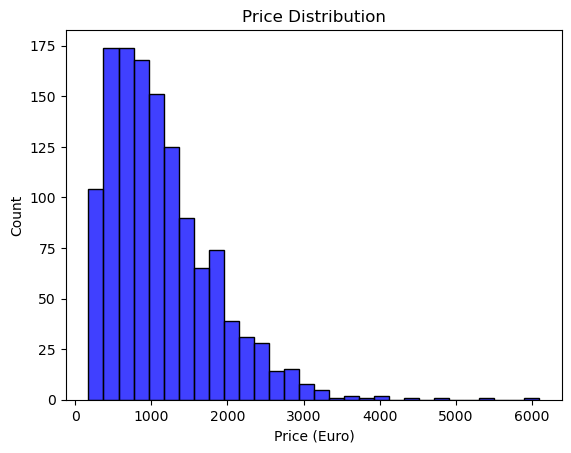

In [48]:
# Check for outliers 
# this section was origionally included earlier but in the report but the descriptice statistics in the cell above are relevent to the analysis.
sns.histplot(df['Price_euros'], bins=30, color='blue').set(xlabel='Price (Euro)', title='Price Distribution')

In [49]:
#Get Outliers
df[df['Price_euros'] > 4000]

,Company,Product,TypeName,Inches,Ram,OS,Weight,Price_euros,Screen,ScreenW,...,PrimaryStorage,SecondaryStorage,PrimaryStorageType,SecondaryStorageType,GPU_company,GPU_model,StorageSSD,StorageFlash,StorageHDD,StorageHybrid
196,Razer,Blade Pro,Gaming,17.3,32,Windows 10,3.49,6099.0,4K Ultra HD,3840,...,1024,0,SSD,No,Nvidia,GeForce GTX 1080,1024.0,0.0,0.0,0.0
610,Lenovo,Thinkpad P51,Notebook,15.6,32,Windows 10,2.50,4899.0,4K Ultra HD,3840,...,1024,0,SSD,No,Nvidia,Quadro M2200M,1024.0,0.0,0.0,0.0
749,HP,Zbook 17,Workstation,17.3,16,Windows 7,3.00,4389.0,Full HD,1920,...,256,0,SSD,No,Nvidia,Quadro M2000M,256.0,0.0,0.0,0.0
830,Razer,Blade Pro,Gaming,17.3,32,Windows 10,3.49,5499.0,4K Ultra HD,3840,...,512,0,SSD,No,Nvidia,GeForce GTX 1080,512.0,0.0,0.0,0.0


There are some outlier values for prices outside the €4000-6000 range. A quick google search shows that these laptop prices are far above what laptops of similar models, and the rows were dropped. 

In [51]:
#Remove Outliers
df = df[df['Price_euros'] <= 4000]

[Text(0.5, 0, 'Price (Euro)'), Text(0.5, 1.0, 'Price Distribution')]

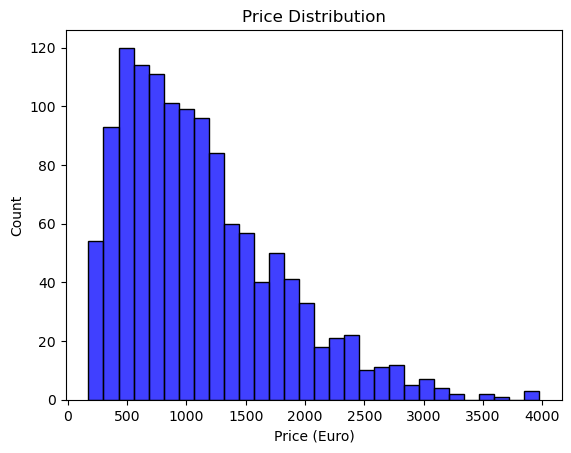

In [52]:
# Check for outliers 
# this section was origionally included earlier but in the report but the descriptice statistics in the cell above are relevent to the analysis.
sns.histplot(df['Price_euros'], bins=30, color='blue').set(xlabel='Price (Euro)', title='Price Distribution')

In [53]:
# Get Total Storage Feature
df["TotalStorage"] = df["PrimaryStorage"] + df["SecondaryStorage"]

C:\Users\resig\AppData\Local\Temp\ipykernel_19680\343906658.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df["TotalStorage"] = df["PrimaryStorage"] + df["SecondaryStorage"]


In [54]:
#Check remaining Columns
header("Check Negative Values")
columns = ["PrimaryStorage","SecondaryStorage","StorageSSD","StorageFlash","StorageHDD","StorageHybrid"]

for i in columns:
    print(i, ":", check_negative_values(df, i).shape[0])

Check Negative Values
PrimaryStorage : 0
SecondaryStorage : 0
StorageSSD : 0
StorageFlash : 0
StorageHDD : 0
StorageHybrid : 0


In [55]:
# The laptop prices data will be seperated into Numeric and Categorial to assess summary statistics
# issues exist and what corrections must be made to address these issues
dfSplit = split_data(df)

dfNumeric = dfSplit['numeric']
dfCategorical = dfSplit['categorical']

#### Categorical Data

In [57]:
# Inspect Categorical Data
dfCategorical

,Company,Product,TypeName,OS,Screen,Touchscreen,IPSpanel,RetinaDisplay,CPU_company,CPU_model,PrimaryStorageType,SecondaryStorageType,GPU_company,GPU_model
0,Apple,MacBook Pro,Ultrabook,macOS,Standard,False,True,True,Intel,Core i5,SSD,No,Intel,Iris Plus Graphics 640
1,Apple,Macbook Air,Ultrabook,macOS,Standard,False,False,False,Intel,Core i5,Flash Storage,No,Intel,HD Graphics 6000
2,HP,250 G6,Notebook,No OS,Full HD,False,False,False,Intel,Core i5 7200U,SSD,No,Intel,HD Graphics 620
3,Apple,MacBook Pro,Ultrabook,macOS,Standard,False,True,True,Intel,Core i7,SSD,No,AMD,Radeon Pro 455
4,Apple,MacBook Pro,Ultrabook,macOS,Standard,False,True,True,Intel,Core i5,SSD,No,Intel,Iris Plus Graphics 650
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1270,Lenovo,Yoga 500-14ISK,2 in 1 Convertible,Windows 10,Full HD,True,True,False,Intel,Core i7 6500U,SSD,No,Intel,HD Graphics 520
1271,Lenovo,Yoga 900-13ISK,2 in 1 Convertible,Windows 10,Quad HD+,True,True,False,Intel,Core i7 6500U,SSD,No,Intel,HD Graphics 520
1272,Lenovo,IdeaPad 100S-14IBR,Notebook,Windows 10,Standard,False,False,False,Intel,Celeron Dual Core N3050,Flash Storage,No,Intel,HD Graphics
1273,HP,15-AC110nv (i7-6500U/6GB/1TB/Radeon,Notebook,Windows 10,Standard,False,False,False,Intel,Core i7 6500U,HDD,No,AMD,Radeon R5 M330


In [58]:
# Generate Summary Categorical Data
get_categorical_details(dfCategorical)

,count,unique,mode,freq_mode,freq_mode(%),2ndmode,freq_2ndmode,freq_2ndmode(%)
Company,1271,19,Dell,291,0.228954,Lenovo,288,0.226593
Product,1271,617,XPS 13,30,0.023603,Inspiron 3567,25,0.01967
TypeName,1271,6,Notebook,706,0.555468,Gaming,203,0.159717
OS,1271,9,Windows 10,1045,0.822187,No OS,66,0.051928
Screen,1271,4,Full HD,834,0.656176,Standard,369,0.290323
Touchscreen,1271,2,False,1085,0.853659,True,186,0.146341
IPSpanel,1271,2,False,916,0.720692,True,355,0.279308
RetinaDisplay,1271,2,False,1254,0.986625,True,17,0.013375
CPU_company,1271,3,Intel,1210,0.952006,AMD,60,0.047207
CPU_model,1271,91,Core i5 7200U,193,0.151849,Core i7 7700HQ,147,0.115657


#### Numeric Data

In [60]:
# Inspect Continuous Data
dfNumeric

,Inches,Ram,Weight,Price_euros,ScreenW,ScreenH,CPU_freq,PrimaryStorage,SecondaryStorage,StorageSSD,StorageFlash,StorageHDD,StorageHybrid,TotalStorage
0,13.3,8,1.37,1339.69,2560,1600,2.3,128,0,128.0,0.0,0.0,0.0,128
1,13.3,8,1.34,898.94,1440,900,1.8,128,0,0.0,128.0,0.0,0.0,128
2,15.6,8,1.86,575.00,1920,1080,2.5,256,0,256.0,0.0,0.0,0.0,256
3,15.4,16,1.83,2537.45,2880,1800,2.7,512,0,512.0,0.0,0.0,0.0,512
4,13.3,8,1.37,1803.60,2560,1600,3.1,256,0,256.0,0.0,0.0,0.0,256
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1270,14.0,4,1.80,638.00,1920,1080,2.5,128,0,128.0,0.0,0.0,0.0,128
1271,13.3,16,1.30,1499.00,3200,1800,2.5,512,0,512.0,0.0,0.0,0.0,512
1272,14.0,2,1.50,229.00,1366,768,1.6,64,0,0.0,64.0,0.0,0.0,64
1273,15.6,6,2.19,764.00,1366,768,2.5,1024,0,0.0,0.0,1024.0,0.0,1024


In [61]:
# Generate Summary of numeric Data
get_continuous_details(dfNumeric)

,count,mean,std,min,25%,50%,75%,max,Unique
Inches,1271.0,15.017073,1.427331,10.10,14.0,15.60,15.6,18.4,18
Ram,1271.0,8.379229,4.970877,2.00,4.0,8.00,8.0,64.0,9
Weight,1271.0,2.037128,0.667100,0.69,1.5,2.04,2.3,4.7,171
Price_euros,1271.0,1122.108222,662.225815,174.00,606.0,985.00,1491.4,3975.0,787
ScreenW,1271.0,1895.449253,485.021248,1366.00,1920.0,1920.00,1920.0,3840.0,13
ScreenH,1271.0,1071.335956,279.375771,768.00,1080.0,1080.00,1080.0,2160.0,10
CPU_freq,1271.0,2.300944,0.503303,0.90,2.0,2.50,2.7,3.6,25
PrimaryStorage,1271.0,443.701023,365.345888,8.00,256.0,256.00,512.0,2048.0,13
SecondaryStorage,1271.0,176.623131,416.497630,0.00,0.0,0.00,0.0,2048.0,6
StorageSSD,1271.0,184.632573,184.952864,0.00,0.0,256.00,256.0,1024.0,12


## PCPartsPicker

### Headphones

In [64]:
header("Data Types: Headphones")
dfHeadphones.dtypes

Data Types: Headphones


brand                 object
model                 object
form_factor           object
frequency_response    object
has_microphone          bool
is_wireless             bool
color                 object
price                 object
dtype: object

In [65]:
dfHeadphones

,brand,model,form_factor,frequency_response,has_microphone,is_wireless,color,price
0,1MORE,EHD9001TA,In Ear,None,False,True,Black / Red,US$0.00
1,1MORE,Quad Driver,In Ear,"FrequencyResponse(min=20.0, max=40000.0, defau...",True,False,Black / Red,US$124.23
2,1MORE,Triple Driver (Black/Gold),In Ear,"FrequencyResponse(min=20.0, max=40000.0, defau...",True,False,Black / Gold,US$79.98
3,1MORE,Triple Driver (Silver),In Ear,"FrequencyResponse(min=20.0, max=40000.0, defau...",True,False,Silver,US$67.98
4,1MORE,Triple Driver Lightning (Silver),In Ear,"FrequencyResponse(min=20.0, max=40000.0, defau...",True,False,Silver,US$84.95
...,...,...,...,...,...,...,...,...
2412,Zalman,ZM-HPS10BT,Supra-aural,"FrequencyResponse(min=100.0, max=20000.0, defa...",True,False,Black,US$0.00
2413,Zalman,ZM-RS6F,Circumaural,"FrequencyResponse(min=50.0, max=20000.0, defau...",False,False,Black / Silver,US$0.00
2414,Zalman,ZM-RS6F,Circumaural,"FrequencyResponse(min=50.0, max=20000.0, defau...",False,False,Black,US$0.00
2415,Ziotek,190 0282,Supra-aural,None,False,False,Black,US$0.00


In [66]:
#Print Price (Preadjustment)
dfHeadphones["price"]

0         US$0.00
1       US$124.23
2        US$79.98
3        US$67.98
4        US$84.95
          ...    
2412      US$0.00
2413      US$0.00
2414      US$0.00
2415      US$0.00
2416      US$0.00
Name: price, Length: 2417, dtype: object

In [67]:
#Price (Post Adjustment)
correct_price_column(dfHeadphones)
dfHeadphones['price']

0         0.000000
1       117.248274
2        75.485124
3        64.159524
4        80.175810
           ...    
2412      0.000000
2413      0.000000
2414      0.000000
2415      0.000000
2416      0.000000
Name: price, Length: 2417, dtype: float64

In [68]:
#Confirm that datatypes have been corrected
header("Data Types: Headphones")
dfHeadphones.dtypes

Data Types: Headphones


brand                  object
model                  object
form_factor            object
frequency_response     object
has_microphone           bool
is_wireless              bool
color                  object
price                 float64
dtype: object

In [69]:
#Inital Data Inspection
inspect_data(dfHeadphones)

brand
Sony              261
Sennheiser        230
Audio-Technica    172
Panasonic         143
Skullcandy         93
                 ... 
JayBird             1
Rude Gamewear       1
SHARKOON            1
SIVGA               1
iDeaUSA             1
Name: count, Length: 132, dtype: int64 

model
Siberia v2                9
Kraken Pro Neon           6
A40                       5
SHOCK                     5
Flo                       4
                         ..
99154                     1
61865                     1
61825                     1
Kaliber Gaming NUKLEUS    1
S409                      1
Name: count, Length: 2211, dtype: int64 

form_factor
Circumaural    1070
In Ear          590
Supra-aural     485
Earbud          272
Name: count, dtype: int64 

frequency_response
FrequencyResponse(min=20.0, max=20000.0, default=None)    633
FrequencyResponse(min=18.0, max=22000.0, default=None)     40
FrequencyResponse(min=18.0, max=20000.0, default=None)     39
FrequencyResponse(min=20.0, ma

In [70]:
#Check for Duplicates
dfHeadphonesDuplicateRows = check_duplicates(dfHeadphones)
print("Number of Duplicate Rows: {}".format(dfHeadphonesDuplicateRows))

Number of Duplicate Rows: 0


In [71]:
# Check For Missing Values
inspect_missing_values(dfHeadphones)

[brand                   0
 model                   0
 form_factor             0
 frequency_response    558
 has_microphone          0
 is_wireless             0
 color                   9
 price                   0
 dtype: int64]

In [72]:
#Check what % missing
inspect_missing_values_percentage(dfHeadphones)

brand                  0.000000
model                  0.000000
form_factor            0.000000
frequency_response    23.086471
has_microphone         0.000000
is_wireless            0.000000
color                  0.372362
price                  0.000000
dtype: float64

In [73]:
# Replace missing values with not available
dfHeadphones["frequency_response"] = dfHeadphones["frequency_response"].fillna("not available")
dfHeadphones["color"] = dfHeadphones["color"].fillna("not available")

In [74]:
#check correctly applied to frequency response
dfHeadphones[dfHeadphones["frequency_response"] == "not available"]

,brand,model,form_factor,frequency_response,has_microphone,is_wireless,color,price
0,1MORE,EHD9001TA,In Ear,not available,False,True,Black / Red,0.00000
32,AKG,K350AMA,In Ear,not available,False,False,Purple,0.00000
49,AKG,K618 DJ,Supra-aural,not available,False,False,Black,0.00000
66,AZIO,GH808,Circumaural,not available,True,False,Black / Red,0.00000
78,Adesso,Xtream H3B,Circumaural,not available,False,False,Black / Gray,0.00000
...,...,...,...,...,...,...,...,...
2367,Turtle Beach,Z300,Circumaural,not available,True,False,Black / Red,0.00000
2368,Turtle Beach,Z60,Circumaural,not available,True,False,Black / Red,0.00000
2394,Yamaha,EPH-C500-BL,In Ear,not available,False,False,Black / Silver,113.20881
2395,Yamaha,EPH-C500-WH,In Ear,not available,False,False,White,0.00000


In [75]:
#check correctly applied to color
dfHeadphones[dfHeadphones["color"] == "not available"]

,brand,model,form_factor,frequency_response,has_microphone,is_wireless,color,price
318,Audio-Technica,ATH-WS1100IS,Circumaural,"FrequencyResponse(min=5.0, max=40000.0, defaul...",True,False,not available,182.606424
670,Etymotic Research,ER3 Extended Response,In Ear,"FrequencyResponse(min=20.0, max=16000.0, defau...",False,False,not available,94.332810
671,Etymotic Research,ER3 Studio Edition,In Ear,"FrequencyResponse(min=20.0, max=16000.0, defau...",False,False,not available,131.858298
672,Etymotic Research,ER4 Extended Response,In Ear,"FrequencyResponse(min=20.0, max=16000.0, defau...",False,False,not available,283.092810
673,Etymotic Research,ER4 Studio Reference,In Ear,"FrequencyResponse(min=20.0, max=16000.0, defau...",False,False,not available,264.216810
1126,Panasonic,RP-HJE125-W,Earbud,"FrequencyResponse(min=10.0, max=24000.0, defau...",False,False,not available,8.012862
1319,Philips,ST702BK,In Ear,"FrequencyResponse(min=20.0, max=20000.0, defau...",False,True,not available,0.000000
1611,Sennheiser,HD 4.50 BTNC,Circumaural,"FrequencyResponse(min=18.0, max=22000.0, defau...",True,True,not available,113.246562
1757,Sennheiser,SC 260 USB CTRL II,Supra-aural,"FrequencyResponse(min=50.0, max=18000.0, defau...",True,False,not available,0.000000


In [76]:
dfHeadphones["frequency_response"]

0                                           not available
1       FrequencyResponse(min=20.0, max=40000.0, defau...
2       FrequencyResponse(min=20.0, max=40000.0, defau...
3       FrequencyResponse(min=20.0, max=40000.0, defau...
4       FrequencyResponse(min=20.0, max=40000.0, defau...
                              ...                        
2412    FrequencyResponse(min=100.0, max=20000.0, defa...
2413    FrequencyResponse(min=50.0, max=20000.0, defau...
2414    FrequencyResponse(min=50.0, max=20000.0, defau...
2415                                        not available
2416    FrequencyResponse(min=20.0, max=20000.0, defau...
Name: frequency_response, Length: 2417, dtype: object

In [77]:
#Frequency Response needs to be converted from
dfHeadphones["frequency_response_min"] = dfHeadphones["frequency_response"].loc[dfHeadphones["frequency_response"] != "not available"].apply(lambda x: x.min)
dfHeadphones["frequency_response_min"] = dfHeadphones["frequency_response_min"].fillna(0)
dfHeadphones["frequency_response_max"] = dfHeadphones["frequency_response"].loc[dfHeadphones["frequency_response"] != "not available"].apply(lambda x: x.max)
dfHeadphones["frequency_response_max"] = dfHeadphones["frequency_response_max"].fillna(0)

In [78]:
#Check that the min column was calcualted correcly
dfHeadphones["frequency_response_min"]

0         0.0
1        20.0
2        20.0
3        20.0
4        20.0
        ...  
2412    100.0
2413     50.0
2414     50.0
2415      0.0
2416     20.0
Name: frequency_response_min, Length: 2417, dtype: float64

In [79]:
#Check that the max column was calcualted correcly
dfHeadphones["frequency_response_max"]

0           0.0
1       40000.0
2       40000.0
3       40000.0
4       40000.0
         ...   
2412    20000.0
2413    20000.0
2414    20000.0
2415        0.0
2416    20000.0
Name: frequency_response_max, Length: 2417, dtype: float64

In [80]:
#Remove the old frequency response table
dfHeadphones = dfHeadphones.drop(columns="frequency_response")

[Text(0.5, 0, 'price'), Text(0.5, 1.0, 'Price Distribution')]

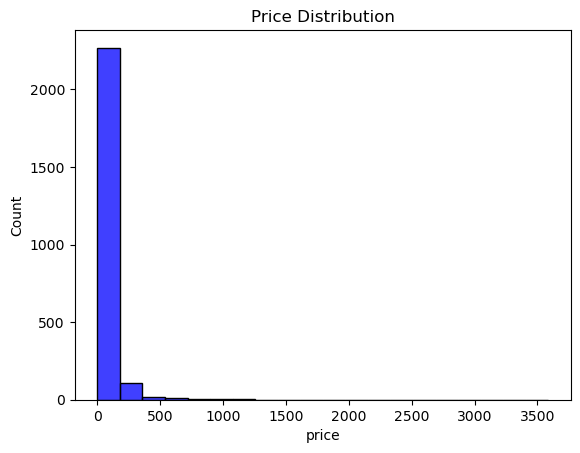

In [81]:
# Price Distribution
sns.histplot(dfHeadphones['price'], bins=20, color='blue').set(xlabel='price', title='Price Distribution')

In [82]:
# Show Outliers
dfHeadphones[dfHeadphones["price"] >= 500]

,brand,model,form_factor,has_microphone,is_wireless,color,price,frequency_response_min,frequency_response_max
155,Audeze,LCD-GX,Circumaural,True,False,Black / Red,848.476200,10.0,50000.0
165,Audio-Technica,ATH-AD2000X,Circumaural,False,False,Black,666.841890,5.0,45000.0
281,Audio-Technica,ATH-IM04,In Ear,False,False,Black,660.650562,15.0,20000.0
351,Beyerdynamic,DT 1770 PRO,Circumaural,False,False,Black,565.336200,5.0,40000.0
362,Beyerdynamic,DT1990 Pro,Circumaural,False,False,Black,545.516400,5.0,40000.0
378,Beyerdynamic,T 5 p,Circumaural,False,False,Black / Silver,706.906200,5.0,50000.0
380,Beyerdynamic,T 90,Circumaural,False,False,Black / Silver,1904.843226,5.0,40000.0
381,Beyerdynamic,T1,Circumaural,False,False,Black / Silver,943.790562,5.0,50000.0
693,Final Audio Design,B1,In Ear,False,False,Copper / Black,659.716200,0.0,0.0
696,Final Audio Design,D8000,Circumaural,False,False,Black / Silver,3585.496200,0.0,0.0


In [83]:
# Remove Outliers where price > 500
dfHeadphones = dfHeadphones[dfHeadphones["price"] <= 500]

[Text(0.5, 0, 'price'), Text(0.5, 1.0, 'Price Distribution of Headphones')]

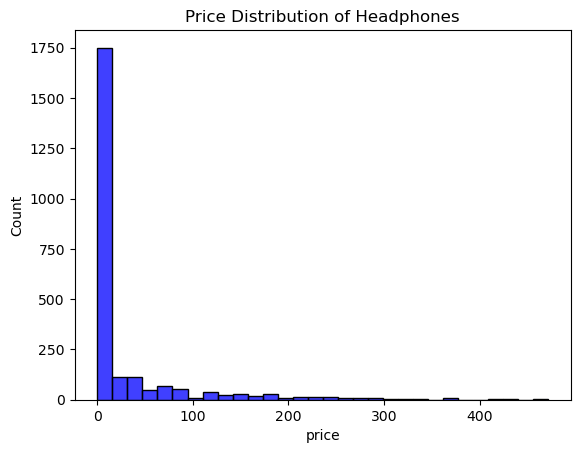

In [84]:
sns.histplot(dfHeadphones['price'], bins=30, color='blue').set(xlabel='price', title='Price Distribution of Headphones')

In [85]:
# The data will be seperated into Numeric and Categorial to assess summary statistics
# issues exist and what corrections must be made to address these issues
dfHeadphonesSplit = split_data(dfHeadphones)

dfHeadphonesNumeric = dfHeadphonesSplit['numeric']
dfHeadphonesCategorical = dfHeadphonesSplit['categorical']

### Categorical Data

In [87]:
dfHeadphonesCategorical

,brand,model,form_factor,has_microphone,is_wireless,color
0,1MORE,EHD9001TA,In Ear,False,True,Black / Red
1,1MORE,Quad Driver,In Ear,True,False,Black / Red
2,1MORE,Triple Driver (Black/Gold),In Ear,True,False,Black / Gold
3,1MORE,Triple Driver (Silver),In Ear,True,False,Silver
4,1MORE,Triple Driver Lightning (Silver),In Ear,True,False,Silver
...,...,...,...,...,...,...
2412,Zalman,ZM-HPS10BT,Supra-aural,True,False,Black
2413,Zalman,ZM-RS6F,Circumaural,False,False,Black / Silver
2414,Zalman,ZM-RS6F,Circumaural,False,False,Black
2415,Ziotek,190 0282,Supra-aural,False,False,Black


In [88]:
get_categorical_details(dfHeadphonesCategorical)

,count,unique,mode,freq_mode,freq_mode(%),2ndmode,freq_2ndmode,freq_2ndmode(%)
brand,2395,132,Sony,260,0.108559,Sennheiser,227,0.094781
model,2395,2191,Siberia v2,9,0.003758,Kraken Pro Neon,6,0.002505
form_factor,2395,4,Circumaural,1056,0.440919,In Ear,586,0.244676
has_microphone,2395,2,False,1302,0.543633,True,1093,0.456367
is_wireless,2395,2,False,2170,0.906054,True,225,0.093946
color,2395,74,Black,630,0.263048,Black / Silver,448,0.187056


### Numeric Data

In [90]:
get_continuous_details(dfHeadphonesNumeric)

,count,mean,std,min,25%,50%,75%,max,Unique
price,2395.0,29.650441,68.320644,0.0,0.0,0.0,21.792342,471.85281,437
frequency_response_min,2395.0,43.625470,734.790967,0.0,5.0,15.0,20.000000,18000.00000,36
frequency_response_max,2395.0,17927.640919,12486.376372,0.0,16000.0,20000.0,23000.000000,230000.00000,52


In [91]:
# It appears that the price column has a large number of missing values. This will need to be address, as price is the target feature
# The previous step (seperating the data) will be repeated with the missing rows removed from the table
dfHeadphonesNoNull = dfHeadphones[dfHeadphones["price"] != 0]

In [92]:
#Checked what % of dataset will remain after removing rows where price = 0
print( str(dfHeadphonesNoNull.shape[0]/dfHeadphones.shape[0] * 100)+"%")

30.146137787056364%


In [93]:
# It appears that the price column has a large number of missing values. This will need to be address, as price is the target feature
# The previous step (seperating the data) will be repeated with the missing rows removed from the table
dfHeadphonesNoNull = dfHeadphones[dfHeadphones["price"] != 0]

# The laptop prices data will be seperated into Numeric and Categorial to assess summary statistics
# issues exist and what corrections must be made to address these issues
dfHeadphonesNoNullSplit = split_data(dfHeadphonesNoNull)

dfHeadphonesNoNullNumeric = dfHeadphonesNoNullSplit['numeric']
dfHeadphonesNoNullCategorical = dfHeadphonesNoNullSplit['categorical']

In [94]:
#Inspect Categorial (again)
get_categorical_details(dfHeadphonesNoNullCategorical)

,count,unique,mode,freq_mode,freq_mode(%),2ndmode,freq_2ndmode,freq_2ndmode(%)
brand,722,85,Sennheiser,73,0.101108,Audio-Technica,54,0.074792
model,722,682,Gaming A10,3,0.004155,F.R.E.Q. 3,3,0.004155
form_factor,722,4,Circumaural,415,0.574792,Supra-aural,132,0.182825
has_microphone,722,2,True,409,0.566482,False,313,0.433518
is_wireless,722,2,False,620,0.858726,True,102,0.141274
color,722,50,Black,221,0.306094,Black / Silver,144,0.199446


In [95]:
#Inspect numeric (again)
get_continuous_details(dfHeadphonesNoNullNumeric)

,count,mean,std,min,25%,50%,75%,max,Unique
price,722.0,98.355686,93.443499,4.709562,28.620735,66.01881,141.52045,471.85281,436
frequency_response_min,722.0,15.422438,20.020383,0.000000,6.000000,18.00000,20.00000,300.00000,28
frequency_response_max,722.0,19420.775623,10747.898441,0.000000,20000.000000,20000.00000,24000.00000,50000.00000,38


### Mouses

In [97]:
header("Data Types: Mouses")
dfMouse.dtypes

Data Types: Mouses


brand                object
model                object
tracking             object
connection           object
max_dpi             float64
hand_orientation     object
color                object
price                object
dtype: object

In [98]:
#Corrected Price Column
dfMouse['price']

0       US$56.00
1       US$99.99
2       US$78.58
3       US$78.69
4        US$0.00
          ...   
2011    US$69.99
2012     US$0.00
2013    US$59.99
2014    US$87.57
2015     US$0.00
Name: price, Length: 2016, dtype: object

In [99]:
correct_price_column(dfMouse)
dfMouse['price']

0       52.852800
1       94.370562
2       74.163804
3       74.267622
4        0.000000
          ...    
2011    66.056562
2012     0.000000
2013    56.618562
2014    82.648566
2015     0.000000
Name: price, Length: 2016, dtype: float64

In [100]:
#Inital Data Inspection
inspect_data(dfMouse)

brand
Logitech      252
Microsoft     204
Razer          84
Verbatim       81
Kensington     78
             ... 
Speedlink       1
Biostar         1
HAVIT           1
Swiftpoint      1
i-rocks         1
Name: count, Length: 138, dtype: int64 

model
M325                      28
M310                      16
M305                      13
Pro Fit Mid-Size Mouse     9
Rival 100                  7
                          ..
FQ983AA#ABA                1
EY703AA                    1
ET424AA                    1
DY651A                     1
IR-7571L-BK                1
Name: count, Length: 1695, dtype: int64 

tracking
Optical      1442
Laser         547
Trackball      17
Touchpad       10
Name: count, dtype: int64 

connection
Wired                 1099
Wireless               810
Bluetooth Wireless     107
Name: count, dtype: int64 

max_dpi
1000.0     263
1600.0     188
8200.0      97
800.0       88
16000.0     80
3200.0      64
12000.0     64
4000.0      61
2000.0      58
1200.0      51
5

In [101]:
#Check for Duplicates
dfMouseDuplicateRows = check_duplicates(dfMouse)
print("Number of Duplicate Rows: {}".format(dfMouseDuplicateRows))

Number of Duplicate Rows: 0


In [102]:
# Check For Missing Values 
inspect_missing_values(dfMouse)

[brand                 0
 model                 0
 tracking              0
 connection            0
 max_dpi             588
 hand_orientation    127
 color                 1
 price                 0
 dtype: int64]

In [103]:
#Check what % missing
inspect_missing_values_percentage(dfMouse)

brand                0.000000
model                0.000000
tracking             0.000000
connection           0.000000
max_dpi             29.166667
hand_orientation     6.299603
color                0.049603
price                0.000000
dtype: float64

In [104]:
# Replace missing values with not available
dfMouse["max_dpi"] = dfMouse["max_dpi"].fillna("not available")
dfMouse["hand_orientation"] = dfMouse["hand_orientation"].fillna("not available")
dfMouse["color"] = dfMouse["color"].fillna("not available")

In [105]:
dfMouse[dfMouse["max_dpi"] == "not available"]

,brand,model,tracking,connection,max_dpi,hand_orientation,color,price
0,3M,EM500GPL,Optical,Wired,not available,Right,Black / Silver,52.852800
1,3M,EM500GPS,Optical,Wired,not available,Right,Black,94.370562
2,3M,EM550GPL,Optical,Wireless,not available,Right,Black,74.163804
3,3M,EM550GPS,Optical,Wireless,not available,Right,Black,74.267622
4,A4Tech,AL90,Laser,Wired,not available,Right,Black,0.000000
...,...,...,...,...,...,...,...,...
1956,Verbatim,Wireless Multi-Trac Blue LED Optical Mouse,Optical,Wireless,not available,Right,Purple,15.695394
1957,Verbatim,Wireless Multi-Trac Blue LED Optical Mouse,Optical,Wireless,not available,Right,Red,14.421264
1958,Verbatim,Wireless Multi-Trac Blue LED Optical Mouse,Optical,Wireless,not available,Right,Black,13.203762
1959,Wacom,EC155W,Optical,Wireless,not available,Both,White,0.000000


In [106]:
dfMouse[dfMouse["hand_orientation"] == "not available"]

,brand,model,tracking,connection,max_dpi,hand_orientation,color,price
71,Adesso,HF-4003UB,Laser,Wired,1600.0,not available,Black,0.000000
78,Adesso,IMOUSE S100,Optical,Bluetooth Wireless,1000.0,not available,Black,0.000000
129,Adesso,iMouse T1,Trackball,Wired,800.0,not available,Silver,0.000000
145,Apple,MB112LL/B,Optical,Wired,not available,not available,White,0.000000
146,Apple,MB829LL/A,Laser,Bluetooth Wireless,not available,not available,White,75.494562
...,...,...,...,...,...,...,...,...
1948,Verbatim,Nano,Optical,Wireless,not available,not available,Pink,0.000000
1949,Verbatim,Nano,Optical,Wireless,not available,not available,Yellow,0.000000
1950,Verbatim,Nano,Optical,Wireless,not available,not available,Purple,0.000000
1951,Verbatim,Nano,Optical,Wireless,not available,not available,Red,0.000000


In [107]:
dfMouse[dfMouse["color"] == "not available"]

,brand,model,tracking,connection,max_dpi,hand_orientation,color,price
1587,Redragon,INQUISITOR M716,Optical,Wired,10000.0,Right,not available,0.0


<Axes: xlabel='price', ylabel='Count'>

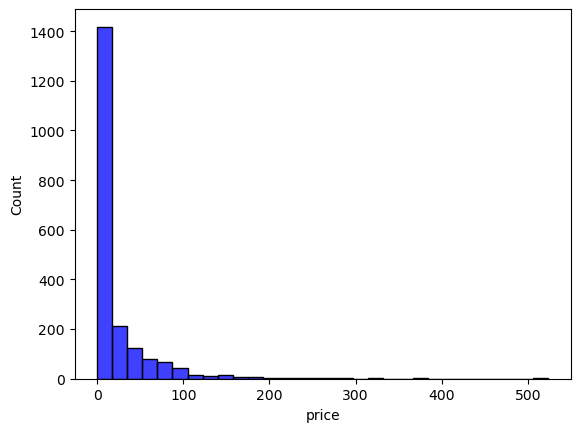

In [108]:
#Check for outliers
sns.histplot(dfMouse['price'], bins=30, color='blue')

In [109]:
dfMouse[dfMouse["price"] > 200]

,brand,model,tracking,connection,max_dpi,hand_orientation,color,price
285,Corsair,DARK CORE RGB,Optical,Wireless,16000.0,Right,Black,378.237288
441,FinalMouse,Air58 Ninja,Optical,Wired,3200.0,Right,Blue,523.790124
890,Logitech,G303 Daedalus Apex,Optical,Wired,12000.0,Right,Black / Orange,375.575772
912,Logitech,G700s,Laser,Wireless,8200.0,Right,Black,330.320562
1088,Logitech,T650,Touchpad,Wireless,not available,Both,Silver,234.959010
1223,Microsoft,9DR-00001,Laser,Bluetooth Wireless,not available,Both,Silver / Black,217.045686
1338,Microsoft,SideWinder X5,Laser,Wired,2000.0,Right,Black,377.510562
1378,Microsoft,Wireless Mobile Mouse 6000,Optical,Wireless,not available,Both,White,264.207372
1395,Mionix,Castor Black,Optical,Wired,5000.0,Right,Black,214.516302
1403,Mionix,Naos 3200,Optical,Wired,3200.0,Right,Black,226.342116


In [110]:
# Remove Outliers
dfMouse = dfMouse[dfMouse["price"] <= 200]

<Axes: xlabel='price', ylabel='Count'>

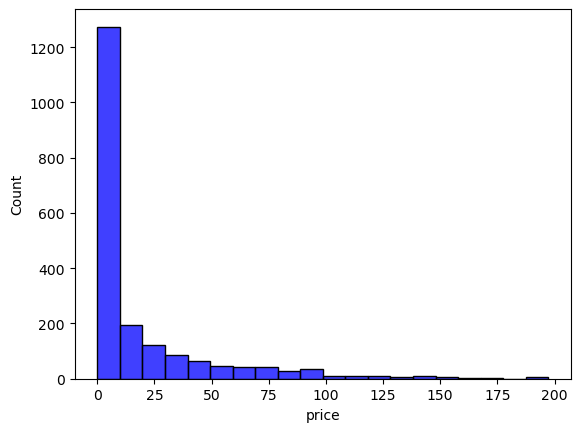

In [111]:
sns.histplot(dfMouse['price'], bins=20, color='blue')

In [112]:
# The data will be seperated into Numeric and Categorial to assess summary statistics
# issues exist and what corrections must be made to address these issues
dfMouseSplit = split_data(dfMouse)

dfMouseNumeric = dfMouseSplit['numeric']
dfMouseCategorical = dfMouseSplit['categorical']

#### Categorical Data

In [114]:
#Inspect Categorical Data
get_categorical_details(dfMouseCategorical)

,count,unique,mode,freq_mode,freq_mode(%),2ndmode,freq_2ndmode,freq_2ndmode(%)
brand,1999,138,Logitech,249,0.124562,Microsoft,201,0.10055
model,1999,1681,M325,28,0.014007,M310,16,0.008004
tracking,1999,4,Optical,1433,0.716858,Laser,540,0.270135
connection,1999,3,Wired,1088,0.544272,Wireless,805,0.402701
max_dpi,1999,57,not available,585,0.292646,1000.0,263,0.131566
hand_orientation,1999,4,Both,984,0.492246,Right,881,0.44072
color,1999,76,Black,840,0.42021,Black / Silver,127,0.063532


#### Numeric Data

In [116]:
#Inspect numeric Data
get_continuous_details(dfMouseNumeric)

,count,mean,std,min,25%,50%,75%,max,Unique
price,1999.0,17.41303,31.813472,0.0,0.0,0.0,22.641762,197.2542,423


In [117]:
# Due to the target feature having missing target features, summary statistics will be computed again excluding where price = 0

In [118]:
# It appears that the price column has a large number of missing values. This will need to be address, as price is the target feature
# The previous step (seperating the data) will be repeated with the missing rows removed from the table
dfMouseNoNull = dfMouse[dfMouse["price"] != 0]

dfMouseNoNullSplit = split_data(dfMouseNoNull)

dfMouseNoNullNumeric = dfMouseNoNullSplit['numeric']
dfMouseNoNullCategorical = dfMouseNoNullSplit['categorical']

In [119]:
#Checked what % of dataset will remain after removing rows where price = 0
print( str(dfMouseNoNullNumeric.shape[0]/dfMouseNumeric.shape[0] * 100)+"%")

37.96898449224612%


In [120]:
#Inspect Categorical Data
get_categorical_details(dfMouseNoNullCategorical)

,count,unique,mode,freq_mode,freq_mode(%),2ndmode,freq_2ndmode,freq_2ndmode(%)
brand,759,70,Logitech,153,0.201581,Microsoft,84,0.110672
model,759,664,M325,18,0.023715,M310,8,0.01054
tracking,759,4,Optical,600,0.790514,Laser,144,0.189723
connection,759,3,Wired,379,0.499341,Wireless,335,0.44137
max_dpi,759,45,not available,264,0.347826,1000.0,110,0.144928
hand_orientation,759,4,Both,389,0.512516,Right,325,0.428195
color,759,58,Black,350,0.461133,Black / Silver,43,0.056653


In [121]:
#Inspect Numeric Data
get_continuous_details(dfMouseNoNullNumeric)

,count,mean,std,min,25%,50%,75%,max,Unique
price,759.0,45.861194,36.896913,4.709562,18.300282,33.778602,65.754546,197.2542,422


### Keyboards

In [123]:
header("Data Types: Keyboards")
dfKeyboard.dtypes

Data Types: Keyboards


brand         object
model         object
style         object
switches      object
backlight     object
tenkeyless      bool
connection    object
color         object
price         object
dtype: object

In [124]:
#Corrected Price Column
dfKeyboard['price']

0         US$0.00
1         US$0.00
2        US$29.99
3         US$0.00
4         US$0.00
          ...    
2337    US$119.95
2338      US$0.00
2339      US$0.00
2340    US$139.95
2341      US$0.00
Name: price, Length: 2342, dtype: object

In [125]:
correct_price_column(dfKeyboard)
dfKeyboard['price']

0         0.000000
1         0.000000
2        28.304562
3         0.000000
4         0.000000
           ...    
2337    113.208810
2338      0.000000
2339      0.000000
2340    132.084810
2341      0.000000
Name: price, Length: 2342, dtype: float64

In [126]:
#Inital Data Inspection
inspect_data(dfKeyboard)

brand
Ducky            262
Logitech         142
Cooler Master    107
Adesso            99
Corsair           97
                ... 
RCA                1
Raptor Gaming      1
Rottay             1
SilentiumPC        1
nMEDIAPC           1
Name: count, Length: 168, dtype: int64 

model
Keyboard           11
Ducky One 2        10
KBT PURE           10
DK9008 Shine II     9
Majestouch-2        8
                   ..
KB009U-B            1
KB008W-B-US         1
KG011-RGB           1
KG011-N             1
HTPCKB-B            1
Name: count, Length: 1884, dtype: int64 

style
Gaming       841
Standard     834
Mini         289
Slim         269
Ergonomic    109
Name: count, dtype: int64 

switches
Cherry MX Brown        200
Cherry MX Blue         199
Cherry MX Red          194
Cherry MX Black        125
Outemu Blue             36
                      ... 
Logitech GL Clicky       1
Logitech GL Tactile      1
Logitech GL Linear       1
GX Red                   1
Flaretech Blue           1
Name: c

In [127]:
#Check for Duplicates
dfKeyboardDuplicateRows = check_duplicates(dfKeyboard)
print("Number of Duplicate Rows: {}".format(dfKeyboardDuplicateRows))

Number of Duplicate Rows: 0


In [128]:
# Check For Missing Values 
inspect_missing_values(dfKeyboard)

[brand            0
 model            0
 style            0
 switches      1217
 backlight     1311
 tenkeyless       0
 connection       0
 color            9
 price            0
 dtype: int64]

In [129]:
# Check For Missing Values %
inspect_missing_values_percentage(dfKeyboard)

brand          0.000000
model          0.000000
style          0.000000
switches      51.964133
backlight     55.977797
tenkeyless     0.000000
connection     0.000000
color          0.384287
price          0.000000
dtype: float64

In [130]:
# Replace missing values with not available
dfKeyboard["switches"] = dfKeyboard["switches"].fillna("not available")
dfKeyboard["backlight"] = dfKeyboard["backlight"].fillna("not available")
dfKeyboard["color"] = dfKeyboard["color"].fillna("not available")

In [131]:
dfKeyboard[dfKeyboard["switches"] == "not available"]

,brand,model,style,switches,backlight,tenkeyless,connection,color,price
1,A4Tech,3100N,Standard,not available,not available,False,Wireless,Black,0.000000
2,A4Tech,7300N,Ergonomic,not available,not available,True,Wireless,Gray / Black,28.304562
3,A4Tech,7700N,Mini,not available,not available,True,Wireless,Silver / Black,0.000000
4,A4Tech,9300F,Ergonomic,not available,not available,False,Wireless,Black,0.000000
5,A4Tech,9500H,Standard,not available,not available,False,Wireless,Black,28.304562
...,...,...,...,...,...,...,...,...,...
2332,matias,FK318PCLBB-KR,Standard,not available,Multicolor,False,Wired,Black,0.000000
2333,matias,FK318PCLBB-ND,Standard,not available,Multicolor,False,Wired,Black,0.000000
2334,matias,FK318PCLBB-PT,Standard,not available,Multicolor,False,Wired,Black,0.000000
2335,matias,FK318PCLBB-UK,Standard,not available,Multicolor,False,Wired,Black,0.000000


In [132]:
dfKeyboard[dfKeyboard["backlight"] == "not available"]

,brand,model,style,switches,backlight,tenkeyless,connection,color,price
1,A4Tech,3100N,Standard,not available,not available,False,Wireless,Black,0.000000
2,A4Tech,7300N,Ergonomic,not available,not available,True,Wireless,Gray / Black,28.304562
3,A4Tech,7700N,Mini,not available,not available,True,Wireless,Silver / Black,0.000000
4,A4Tech,9300F,Ergonomic,not available,not available,False,Wireless,Black,0.000000
5,A4Tech,9500H,Standard,not available,not available,False,Wireless,Black,28.304562
...,...,...,...,...,...,...,...,...,...
2337,matias,Mini Quiet Pro for PC,Mini,ALPS White,not available,True,Wired,Black,113.208810
2338,matias,Quiet Pro Keyboard for Mac,Standard,ALPS White,not available,False,Wired,Black / Silver,0.000000
2339,matias,Quiet Pro Keyboard for PC,Standard,ALPS White,not available,False,Wired,Black,0.000000
2340,matias,Tactile Pro for Mac,Standard,ALPS Clicky Simplified White,not available,False,Wired,White,132.084810


In [133]:
dfKeyboard[dfKeyboard["color"] == "not available"]

,brand,model,style,switches,backlight,tenkeyless,connection,color,price
188,Asus,ROG Horus GK2000 RGB UK,Gaming,Cherry MX Red,RGB,False,Wired,not available,0.000000
333,Cooler Master,CK530,Gaming,Gateron Red,RGB,True,Wired,not available,92.737788
394,Cooler Master,MasterKeys Pro M White (MX Blue),Standard,Cherry MX Blue,White,False,Wired,not available,0.000000
451,Corsair,K63 (MX Red w/Blue LED),Gaming,Cherry MX Red,Blue,True,Wireless,not available,103.808562
452,Corsair,K63 Lapboard Combo (MX Red w/Blue LED),Gaming,Cherry MX Red,Blue,True,Wireless,not available,281.242962
453,Corsair,K63 Special Edition (MX Red),Gaming,Cherry MX Red,Blue,True,Wireless,not available,159.039738
522,Corsair,STRAFE RGB MK.2,Gaming,Cherry MX Red,RGB,False,Wired,not available,106.639962
523,Corsair,STRAFE RGB MK.2,Gaming,Cherry MX Silent,RGB,False,Wired,not available,0.000000
1890,Rii,RK100,Standard,not available,Multicolor,False,Wired,not available,0.000000


[Text(0.5, 0, 'price'), Text(0.5, 1.0, 'Price Distribution')]

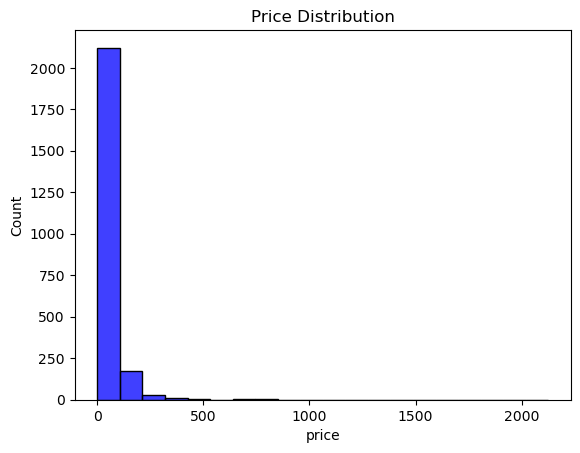

In [134]:
# Check for Outliers
sns.histplot(dfKeyboard['price'], bins=20, color='blue').set(xlabel='price', title='Price Distribution')

In [135]:
# Show Outliers
dfKeyboard[dfKeyboard["price"] >= 400]

,brand,model,style,switches,backlight,tenkeyless,connection,color,price
298,Cherry,J86-4400 Vandal-Proof Keyboard,Slim,not available,not available,False,Wired,Gray,638.254188
1159,IOGEAR,GKM571R,Mini,not available,not available,True,Wireless,Black,470.956200
1425,Logitech,G19,Standard,not available,Multicolor,False,Wired,Black,744.658200
1431,Logitech,G510,Gaming,not available,Multicolor,False,Wired,Black,755.030562
1520,Logitech,MX 5500 Revolution,Standard,not available,not available,False,Wireless,Black,754.973934
1650,Microsoft,WTA-00001,Ergonomic,not available,not available,False,Wireless,Black / Silver,734.059326
2162,Topre,Realforce 104U,Standard,Topre Variable,not available,False,Wired,White / Gray,454.722840
2165,Topre,Realforce 87U,Slim,Topre 55g,Blue,True,Wired,White / Gray,2125.277154
2166,Topre,Realforce 87U,Slim,Topre Variable,Blue,True,Wired,Black,768.460836
2168,Topre,Realforce 87U,Slim,Topre Variable,Blue,True,Wired,White / Gray,695.137014


In [136]:
# Remove Outliers where price > 400
dfKeyboard = dfKeyboard[dfKeyboard["price"] <= 400]

[Text(0.5, 0, 'price'), Text(0.5, 1.0, 'Price Distribution')]

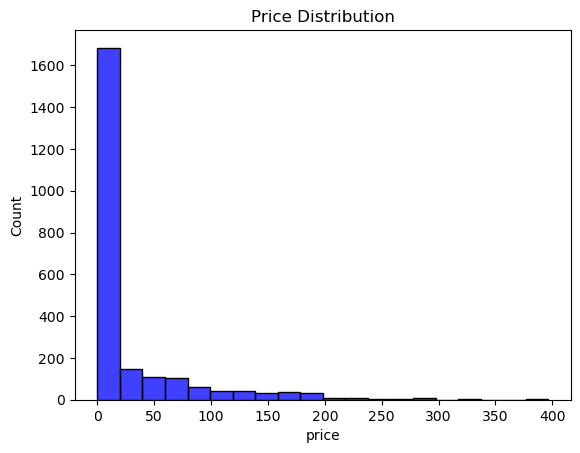

In [137]:
sns.histplot(dfKeyboard['price'], bins=20, color='blue').set(xlabel='price', title='Price Distribution')

In [138]:
# The laptop prices data will be seperated into Numeric and Categorial to assess summary statistics
# issues exist and what corrections must be made to address these issues
dfKeyboardSplit = split_data(dfKeyboard)

dfKeyboardNumeric = dfKeyboardSplit['numeric']
dfKeyboardCategorical = dfKeyboardSplit['categorical']

#### Categorical Data

In [140]:
#Inspect Categorical Data
get_categorical_details(dfKeyboardCategorical)

,count,unique,mode,freq_mode,freq_mode(%),2ndmode,freq_2ndmode,freq_2ndmode(%)
brand,2331,168,Ducky,262,0.112398,Logitech,139,0.059631
model,2331,1877,Keyboard,11,0.004719,KBT PURE,10,0.00429
style,2331,5,Gaming,840,0.36036,Standard,831,0.356499
switches,2331,91,not available,1211,0.51952,Cherry MX Brown,200,0.0858
backlight,2331,12,not available,1306,0.560275,RGB,401,0.172029
tenkeyless,2331,2,False,1774,0.761047,True,557,0.238953
connection,2331,3,Wired,1906,0.817675,Wireless,329,0.141141
color,2331,41,Black,1832,0.785929,White,114,0.048906


#### Numeric Data

In [142]:
#Inspect numeric Data
get_continuous_details(dfKeyboardNumeric)

,count,mean,std,min,25%,50%,75%,max,Unique
price,2331.0,26.331198,54.680074,0.0,0.0,0.0,28.663206,396.386562,413


In [143]:
# It appears that the price column has a large number of missing values. This will need to be address, as price is the target feature
# The previous step (seperating the data) will be repeated with the missing rows removed from the table
dfKeyboardNoNull = dfKeyboard[dfKeyboard["price"] != 0]

# The prices data will be seperated into Numeric and Categorial to assess summary statistics
# issues exist and what corrections must be made to address these issues
dfKeyboardNoNullSplit = split_data(dfKeyboardNoNull)

dfKeyboardNoNullNumeric = dfKeyboardNoNullSplit['numeric']
dfKeyboardNoNullCategorical = dfKeyboardNoNullSplit['categorical']

In [144]:
#Checked what % of dataset will remain after removing rows where price = 0
print( str(dfKeyboardNoNullNumeric.shape[0]/dfKeyboardNumeric.shape[0] * 100)+"%")

30.28743028743029%


In [145]:
#Inspect Categorical Data
get_categorical_details(dfKeyboardNoNullCategorical)

,count,unique,mode,freq_mode,freq_mode(%),2ndmode,freq_2ndmode,freq_2ndmode(%)
brand,706,90,Logitech,84,0.11898,Adesso,54,0.076487
model,706,602,RK71,6,0.008499,CTRL,6,0.008499
style,706,5,Gaming,256,0.362606,Standard,213,0.3017
switches,706,65,not available,437,0.61898,Cherry MX Red,33,0.046742
backlight,706,10,not available,418,0.592068,RGB,173,0.245042
tenkeyless,706,2,False,553,0.783286,True,153,0.216714
connection,706,3,Wired,526,0.745042,Wireless,132,0.186969
color,706,26,Black,570,0.807365,White,33,0.046742


In [146]:
#Inspect numeric data
get_continuous_details(dfKeyboardNoNullNumeric)

,count,mean,std,min,25%,50%,75%,max,Unique
price,706.0,86.937709,67.860762,7.069062,36.145181,66.047124,121.7502,396.386562,412


# 5. Data Visualization

In [148]:
#Note: When analysing 
def boxplot_statistics(feature):
    #provides the statistics from the boxplot analysis of a particular feature passed as the parameter above

    stats = {}

    #get statistics grouped by feature
    for i in list(df[feature].unique()):
        groupPrices = df[df[feature] == i]["Price_euros"]
        stats[i] = {
            'Mean': groupPrices.mean(),
            'Std': groupPrices.std(),
            'Min': groupPrices.min(),
            '25%': groupPrices.quantile(0.25),
            '50% (Median)': groupPrices.median(),
            '75%': groupPrices.quantile(0.75),
            'Max': groupPrices.max(),
        }
    statsDf = pd.DataFrame(stats).T
    print(statsDf.to_string())

## Laptop Prices

### Univariate Analysis


[Text(0.5, 0, 'Price (Euro)'), Text(0.5, 1.0, 'Price Distribution of Laptops')]

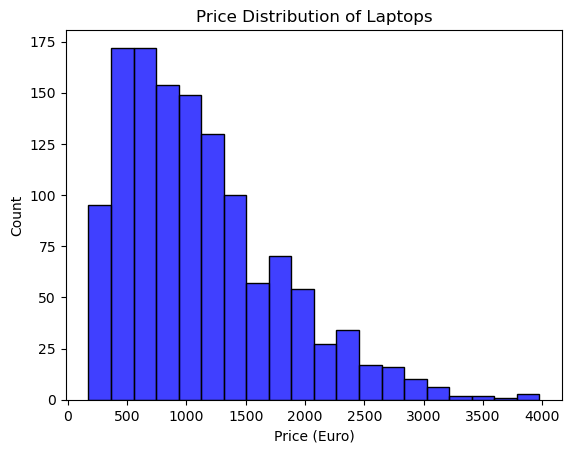

In [151]:
# Price Distribution
sns.histplot(df['Price_euros'], bins=20, color='blue').set(xlabel='Price (Euro)', title='Price Distribution of Laptops')

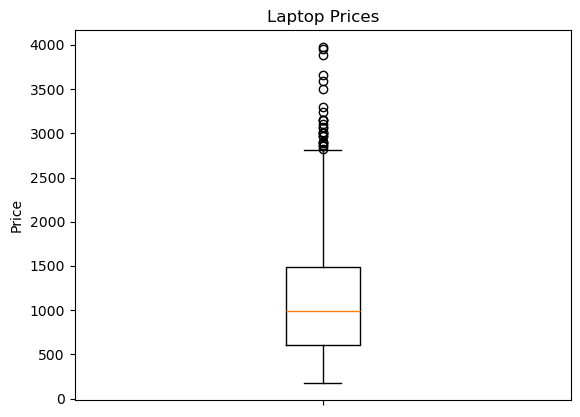

In [152]:
# Price Distribution (As box plots)
plt.boxplot(df['Price_euros'])
plt.ylabel('Price')
plt.title("Laptop Prices")
plt.xticks([1],[""])
plt.show()

C:\Users\resig\AppData\Local\Temp\ipykernel_19680\2752225069.py:5: FutureWarning: The behavior of obj[i:j] with a float-dtype index is deprecated. In a future version, this will be treated as positional instead of label-based. For label-based slicing, use obj.loc[i:j] instead
  sortedCounts[1:].plot(kind='bar')


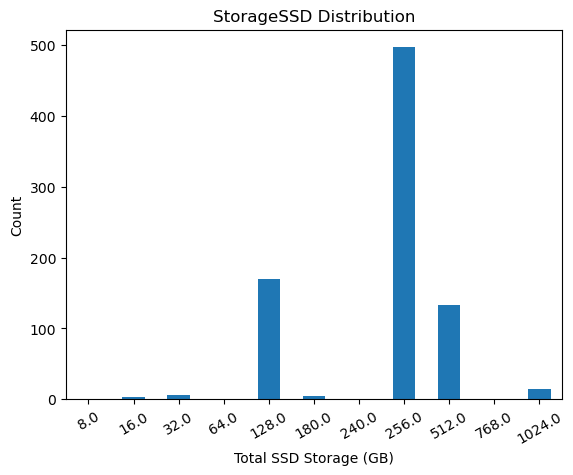

In [153]:
# SSD Storage (of devcices that had SSD storage)
sortedCounts = df['StorageSSD'].value_counts().sort_index()

# Plot the sorted value counts
sortedCounts[1:].plot(kind='bar')

# Set labels and title
plt.ylabel("Count")
plt.title('StorageSSD Distribution')
plt.xlabel("Total SSD Storage (GB)")
plt.xticks(rotation=30)

# Show the plot
plt.show()

C:\Users\resig\AppData\Local\Temp\ipykernel_19680\1969239295.py:5: FutureWarning: The behavior of obj[i:j] with a float-dtype index is deprecated. In a future version, this will be treated as positional instead of label-based. For label-based slicing, use obj.loc[i:j] instead
  sortedCounts[1:].plot(kind='bar')


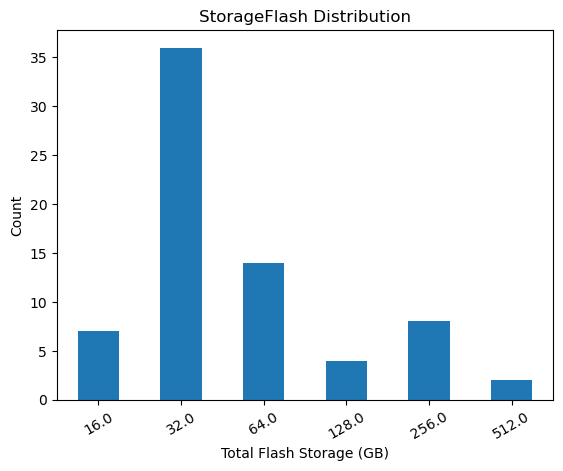

In [154]:
# SStorageFlash
sortedCounts = df['StorageFlash'].value_counts().sort_index()

# Plot the sorted value counts
sortedCounts[1:].plot(kind='bar')

# Set labels and title
plt.ylabel("Count")
plt.title('StorageFlash Distribution')
plt.xlabel("Total Flash Storage (GB)")
plt.xticks(rotation=30)

# Show the plot
plt.show()

C:\Users\resig\AppData\Local\Temp\ipykernel_19680\1207930229.py:5: FutureWarning: The behavior of obj[i:j] with a float-dtype index is deprecated. In a future version, this will be treated as positional instead of label-based. For label-based slicing, use obj.loc[i:j] instead
  sortedCounts[1:].plot(kind='bar')


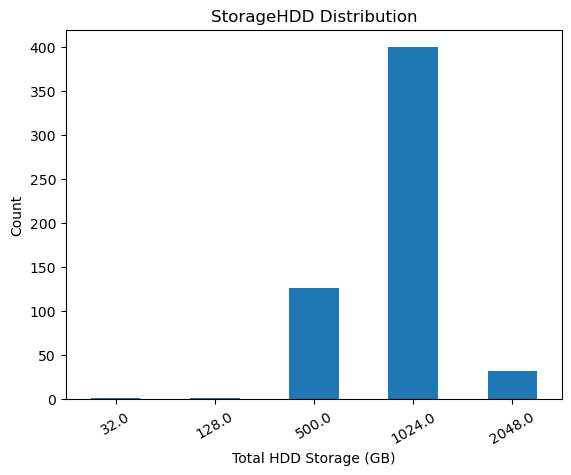

In [155]:
# StorageHDD
sortedCounts = df['StorageHDD'].value_counts().sort_index()

# Plot the sorted value counts
sortedCounts[1:].plot(kind='bar')

# Set labels and title
plt.ylabel("Count")
plt.title('StorageHDD Distribution')
plt.xlabel("Total HDD Storage (GB)")
plt.xticks(rotation=30)

# Show the plot
plt.show()

C:\Users\resig\AppData\Local\Temp\ipykernel_19680\647088439.py:5: FutureWarning: The behavior of obj[i:j] with a float-dtype index is deprecated. In a future version, this will be treated as positional instead of label-based. For label-based slicing, use obj.loc[i:j] instead
  sortedCounts[1:].plot(kind='bar')


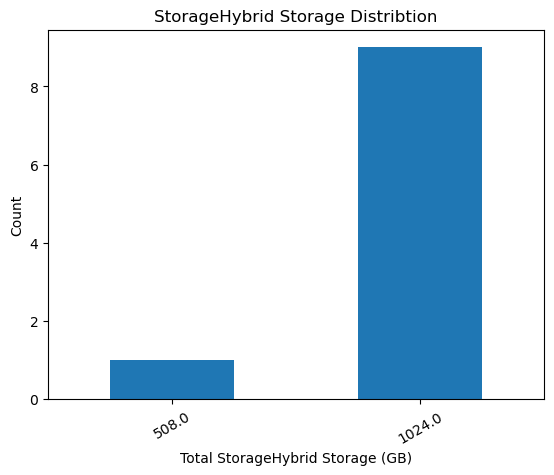

In [156]:
# StorageHybrid
sortedCounts = df['StorageHybrid'].value_counts().sort_index()

# Plot the sorted value counts
sortedCounts[1:].plot(kind='bar')

# Set labels and title
plt.ylabel("Count")
plt.xlabel("Total StorageHybrid Storage (GB)")
plt.title('StorageHybrid Storage Distribtion')
plt.xticks(rotation=30)

# Show the plot
plt.show()

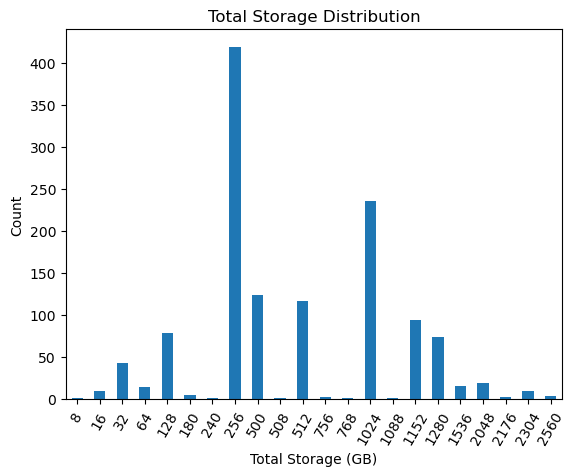

In [157]:
# Total Storage
sortedCounts = df['TotalStorage'].value_counts().sort_index()

# Plot the sorted value counts
sortedCounts.plot(kind='bar')

# Set labels and title
plt.ylabel("Count")
plt.title('Total Storage Distribution')
plt.xlabel("Total Storage (GB)")
plt.xticks(rotation=60)

# Show the plot
plt.show()

[Text(0.5, 0, 'Storage (GB)'), Text(0.5, 1.0, 'Total Storage Distribution')]

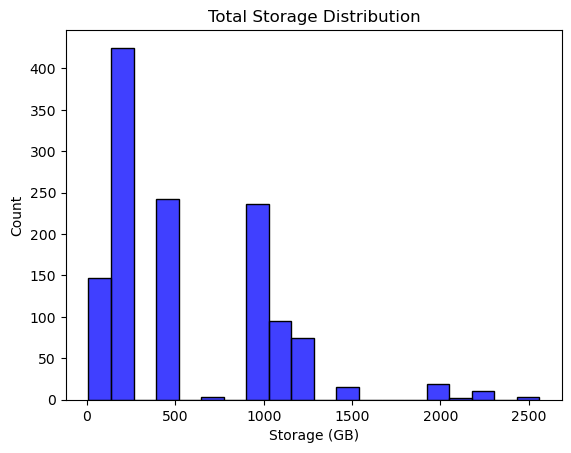

In [158]:
#Total Storage
sns.histplot(df['TotalStorage'], bins=20, color='blue').set(xlabel='Storage (GB)', title='Total Storage Distribution')

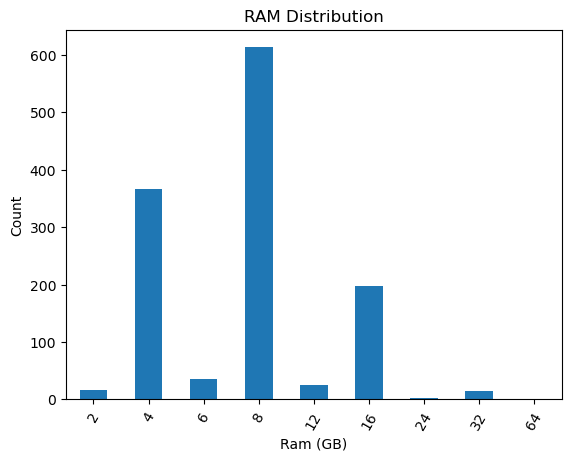

In [159]:
#RAM
sortedRam = df['Ram'].value_counts().sort_index()

# Plot the sorted value counts
sortedRam.plot(kind='bar')

# Set labels and title
plt.ylabel("Count")
plt.title('RAM Distribution')
plt.xticks(rotation=60)
plt.xlabel("Ram (GB)")

# Show the plot
plt.show()

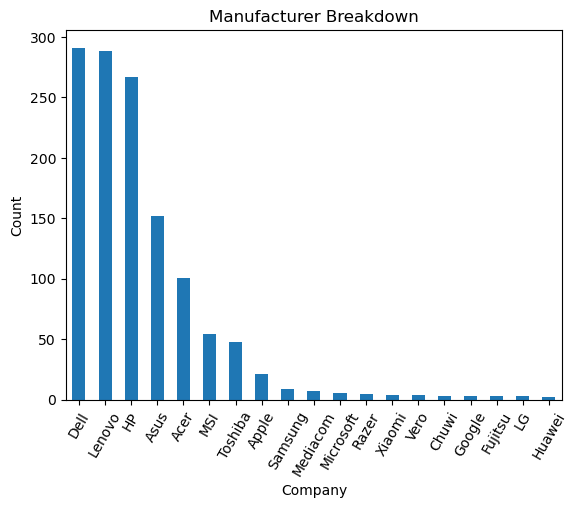

In [160]:
#'Company'
df['Company'].value_counts().plot(kind='bar')
plt.ylabel("Count")
plt.title('Manufacturer Breakdown')
plt.xticks(rotation=60)
plt.show()

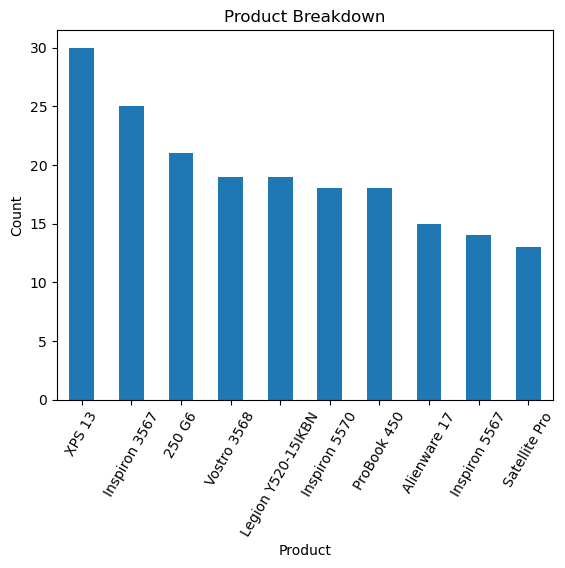

In [161]:
#'Product'
df['Product'].value_counts()[0:10].plot(kind='bar')
plt.ylabel("Count")
plt.title('Product Breakdown')
plt.xticks(rotation=60)
plt.show()

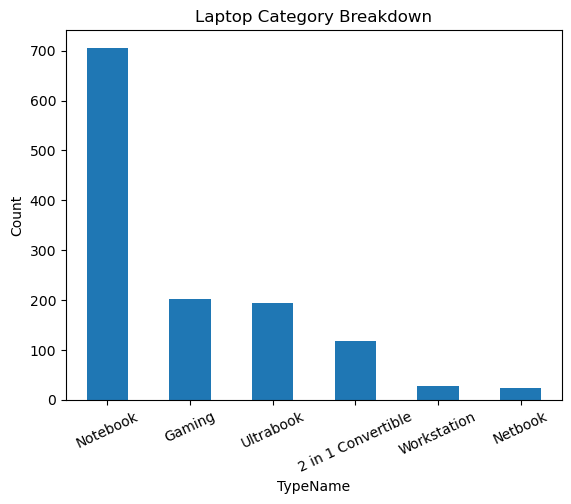

In [162]:
#'TypeName'
df['TypeName'].value_counts().plot(kind='bar')
plt.ylabel("Count")
plt.title('Laptop Category Breakdown')
plt.xticks(rotation=25)
plt.show()

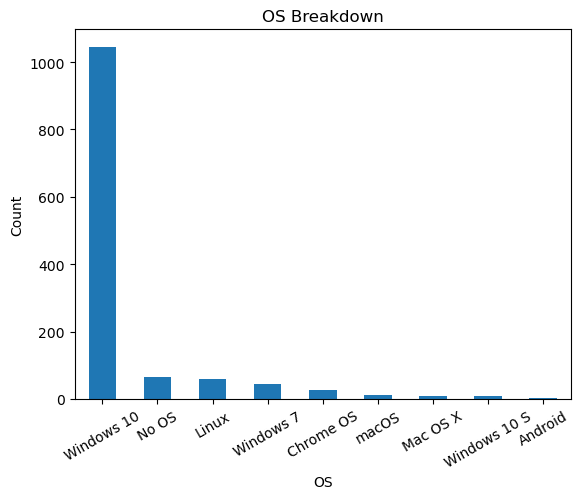

In [163]:
#'OS'
df['OS'].value_counts().plot(kind='bar')
plt.ylabel("Count")
plt.title('OS Breakdown')
plt.xticks(rotation=30)
plt.show()

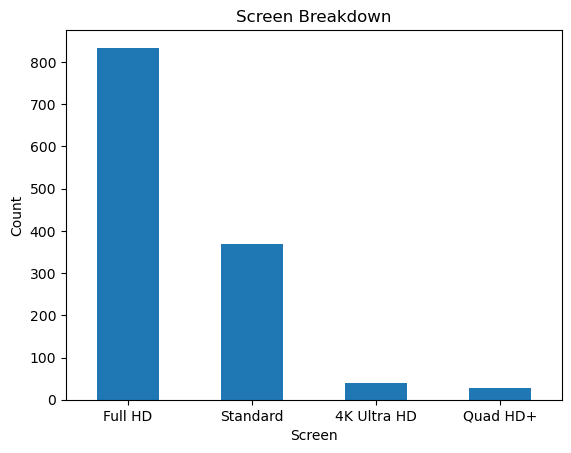

In [164]:
# Screen
df['Screen'].value_counts().plot(kind='bar')
plt.ylabel("Count")
plt.title('Screen Breakdown')
plt.xticks(rotation=0)
plt.show()

In [165]:
#Show % breakdown
(df['Screen'].value_counts()/df['OS'].shape[0]) * 100

Screen
Full HD        65.617624
Standard       29.032258
4K Ultra HD     3.147128
Quad HD+        2.202990
Name: count, dtype: float64

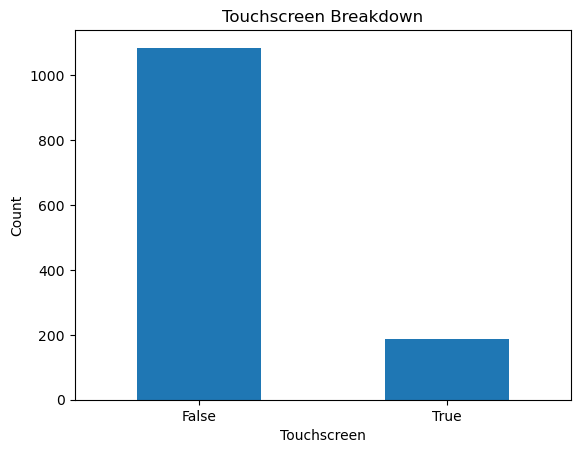

In [166]:
# Touchscreen
#print('Touchscreen')
df['Touchscreen'].value_counts().plot(kind='bar')
plt.ylabel("Count")
plt.title('Touchscreen Breakdown')
plt.xticks(rotation=0)
plt.show()

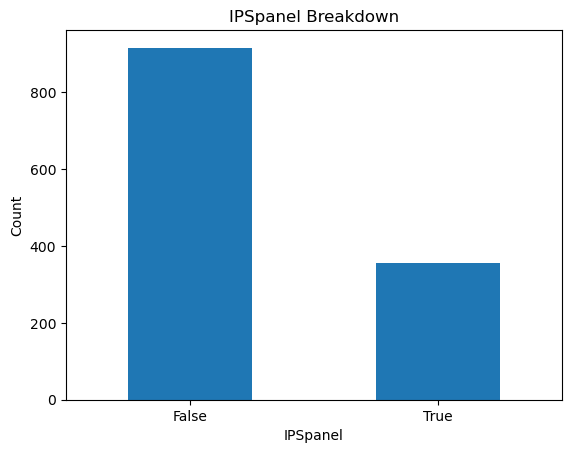

In [167]:
# IPSpanel
df['IPSpanel'].value_counts().plot(kind='bar')
plt.ylabel("Count")
plt.title('IPSpanel Breakdown')
plt.xticks(rotation=0)
plt.show()

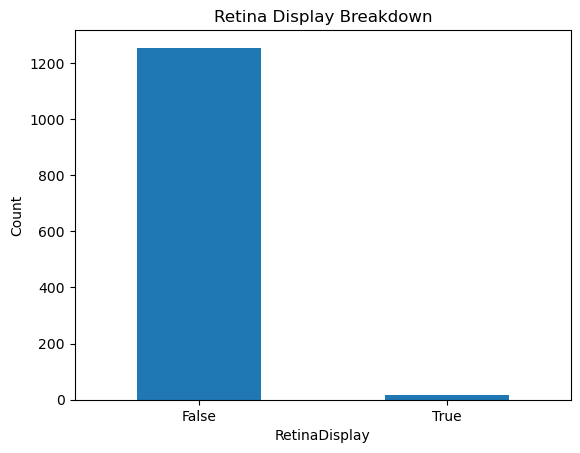

In [168]:
#RetinaDisplay
df['RetinaDisplay'].value_counts().plot(kind='bar')
plt.ylabel("Count")
plt.title('Retina Display Breakdown')
plt.xticks(rotation=0)
plt.show()

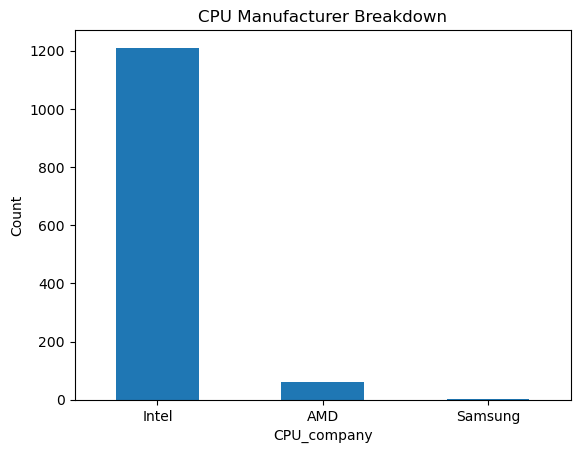

In [169]:
#CPU_company
df['CPU_company'].value_counts().plot(kind='bar')
plt.ylabel("Count")
plt.title('CPU Manufacturer Breakdown')
plt.xticks(rotation=0)
plt.show()

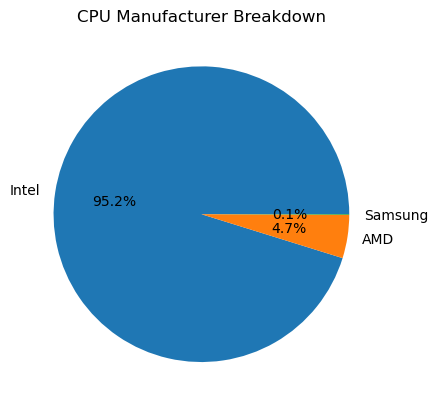

In [170]:
#'OS'
df['CPU_company'].value_counts().plot(kind='pie', autopct='%1.1f%%')
plt.ylabel("")
plt.title('CPU Manufacturer Breakdown')
plt.show()

In [171]:
#Show % breakdown
(df['CPU_company'].value_counts()/df['OS'].shape[0]) * 100

CPU_company
Intel      95.200629
AMD         4.720692
Samsung     0.078678
Name: count, dtype: float64

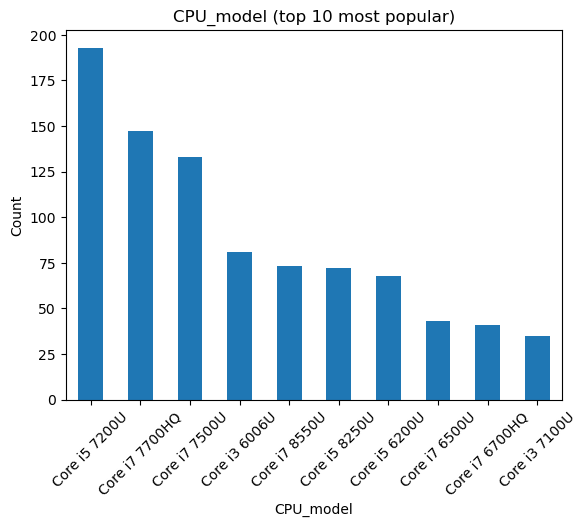

In [172]:
#CPU Model
df['CPU_model'].value_counts()[:10].plot(kind='bar')
plt.ylabel("Count")
plt.title('CPU_model (top 10 most popular)')
plt.xticks(rotation=45)
plt.show()

The CPU Model Graph was excluded from the report as it was not possible to derive any meaningful information from the graph.

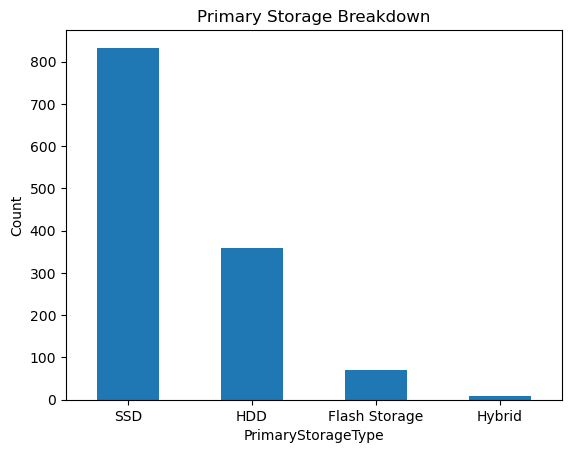

In [174]:
# PrimaryStorageType
df['PrimaryStorageType'].value_counts().plot(kind='bar')
plt.ylabel("Count")
plt.title('Primary Storage Breakdown')
plt.xticks(rotation=0)
plt.show()

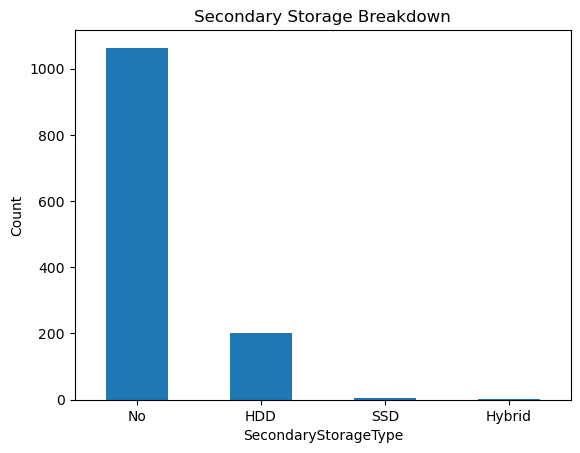

In [175]:
# SecondaryStorageType
df['SecondaryStorageType'].value_counts().plot(kind='bar')
plt.ylabel("Count")
plt.title('Secondary Storage Breakdown')
plt.xticks(rotation=0)
plt.show()

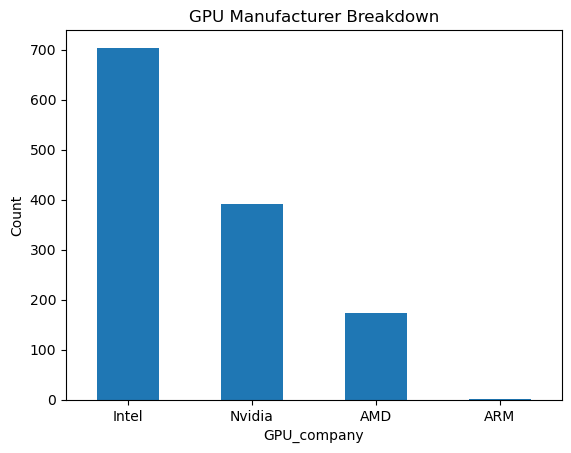

In [176]:
# GPU_company
df['GPU_company'].value_counts().plot(kind='bar')
plt.ylabel("Count")
plt.title('GPU Manufacturer Breakdown')
plt.xticks(rotation=0)
plt.show()

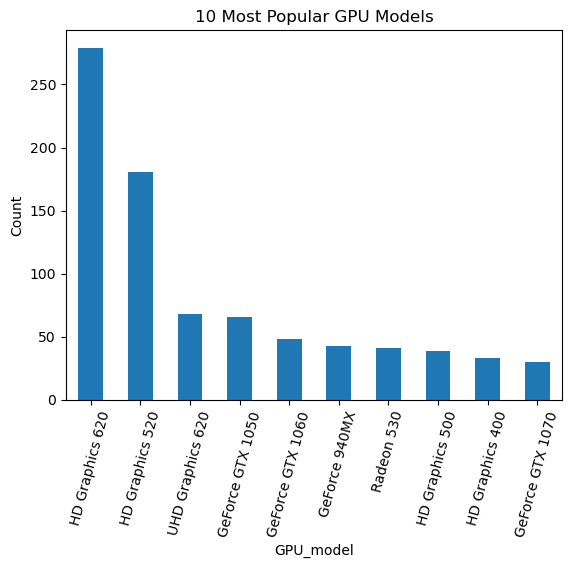

In [177]:
# GPU_model
#print("10 Most Popular GPU Models")
df['GPU_model'].value_counts()[0:10].plot(kind='bar')
plt.ylabel("Count")
plt.title('10 Most Popular GPU Models')
plt.xticks(rotation=75)
plt.show()

### Bivariate Analysis
This section has been organised to reflect the structer of section 6 of the final report

In [179]:
# Calculate Correlation Coefficients
dfSplit['numeric'].corr()

,Inches,Ram,Weight,Price_euros,ScreenW,ScreenH,CPU_freq,PrimaryStorage,SecondaryStorage,StorageSSD,StorageFlash,StorageHDD,StorageHybrid,TotalStorage
Inches,1.000000,0.233007,0.825587,0.045055,-0.081130,-0.106073,0.301796,0.263559,0.392107,-0.114164,-0.227095,0.533729,0.052843,0.538102
Ram,0.233007,1.000000,0.381257,0.725986,0.398831,0.390415,0.360962,0.003878,0.406921,0.586634,-0.056120,0.112201,0.052954,0.354238
Weight,0.825587,0.381257,1.000000,0.192778,-0.045230,-0.066717,0.314721,0.173315,0.486066,-0.070062,-0.177255,0.518342,0.106214,0.550878
Price_euros,0.045055,0.725986,0.192778,1.000000,0.533934,0.530885,0.430805,-0.147986,0.316963,0.664711,-0.036372,-0.086961,0.025696,0.161571
ScreenW,-0.081130,0.398831,-0.045230,0.533934,1.000000,0.993865,0.169959,-0.085080,0.153038,0.504475,-0.011860,-0.113545,-0.000796,0.067691
ScreenH,-0.106073,0.390415,-0.066717,0.530885,0.993865,1.000000,0.155561,-0.092015,0.141632,0.495598,0.021937,-0.125866,-0.002404,0.052592
CPU_freq,0.301796,0.360962,0.314721,0.430805,0.169959,0.155561,1.000000,0.053430,0.226897,0.257661,-0.222956,0.129852,0.049531,0.236346
PrimaryStorage,0.263559,0.003878,0.173315,-0.147986,-0.085080,-0.092015,0.053430,1.000000,-0.243815,-0.213649,-0.094474,0.560832,0.100781,0.546800
SecondaryStorage,0.392107,0.406921,0.486066,0.316963,0.153038,0.141632,0.226897,-0.243815,1.000000,0.106153,-0.058755,0.582401,0.008247,0.678678
StorageSSD,-0.114164,0.586634,-0.070062,0.664711,0.504475,0.495598,0.257661,-0.213649,0.106153,1.000000,-0.147862,-0.395954,-0.049351,-0.070151


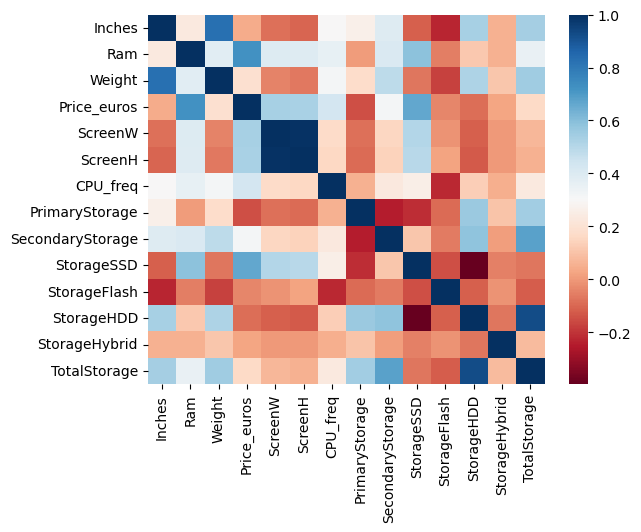

In [180]:
# Compute Correlation Coefficient
sns.heatmap(dfSplit['numeric'].corr(), cmap="RdBu");

In [181]:
#Check the Price Correlation
dfSplit['numeric'].corr().loc["Price_euros",]

Inches              0.045055
Ram                 0.725986
Weight              0.192778
Price_euros         1.000000
ScreenW             0.533934
ScreenH             0.530885
CPU_freq            0.430805
PrimaryStorage     -0.147986
SecondaryStorage    0.316963
StorageSSD          0.664711
StorageFlash       -0.036372
StorageHDD         -0.086961
StorageHybrid       0.025696
TotalStorage        0.161571
Name: Price_euros, dtype: float64

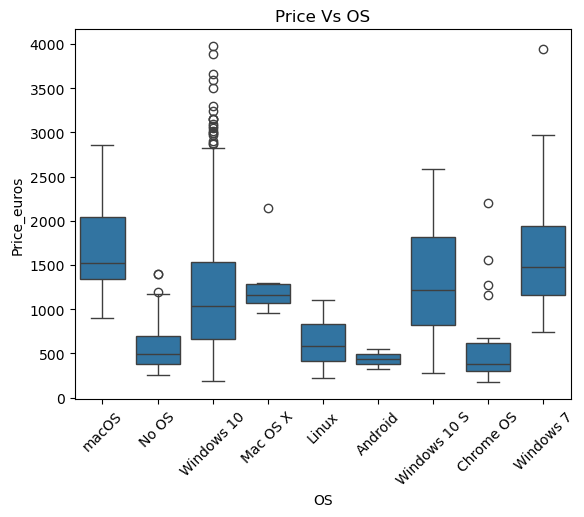

In [182]:
# Investigate Price vs OS
#plt.figure(figsize=(15, 6))

sns.boxplot(x='OS', y='Price_euros', data=df)
plt.xticks(rotation=45)
plt.title("Price Vs OS")
plt.show()

In [183]:
#Get summary for statistics for Prices grouped by OS
boxplot_statistics('OS')

                     Mean         Std     Min       25%  50% (Median)        75%      Max
macOS         1749.630769  588.443390  898.94  1339.690       1518.55  2040.0000  2858.00
No OS          587.973333  277.151691  252.36   375.225        499.00   694.7500  1399.95
Windows 10    1168.286986  658.031020  191.90   659.000       1039.00  1534.0000  3975.00
Mac OS X      1262.871250  374.135623  959.00  1073.750       1164.00  1284.2500  2139.97
Linux          621.867069  251.586973  224.00   412.750        579.26   835.9975  1099.00
Android        434.000000  162.634560  319.00   376.500        434.00   491.5000   549.00
Windows 10 S  1286.480000  787.442491  277.99   826.750       1214.50  1816.2125  2589.00
Chrome OS      553.585185  470.057049  174.00   296.000        375.00   615.0000  2199.00
Windows 7     1625.234318  667.644290  737.00  1159.015       1482.00  1936.8450  3949.40


<Axes: xlabel='PrimaryStorage', ylabel='Price_euros'>

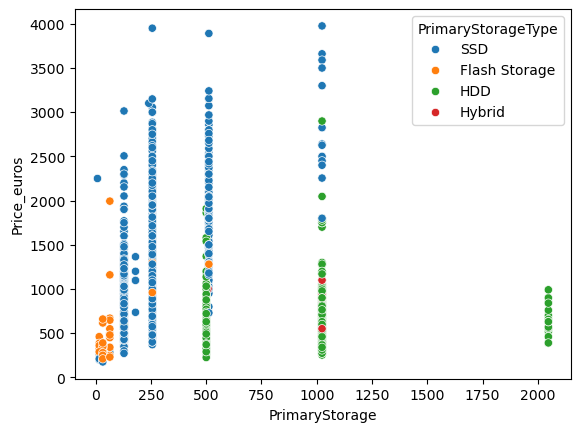

In [184]:
# Storage Distribution (Boxplot)
sns.scatterplot(x='PrimaryStorage', y='Price_euros', data=df, hue='PrimaryStorageType')

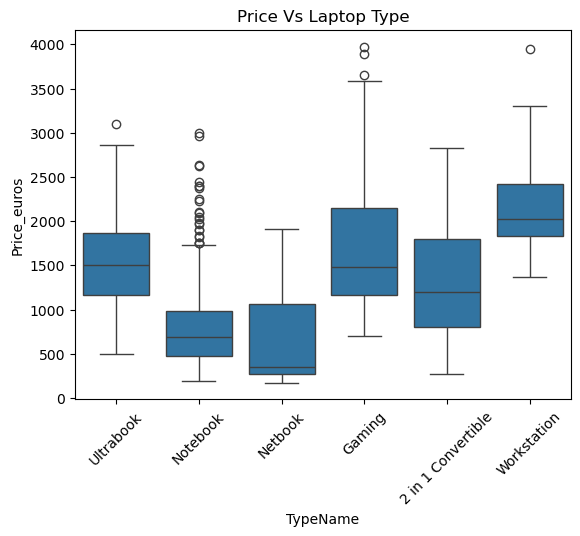

In [185]:
# Investigate Price vs Laptop Type
#plt.figure(figsize=(15, 6))

sns.boxplot(x='TypeName', y='Price_euros', data=df)
plt.title("Price Vs Laptop Type")
plt.xticks(rotation=45)
plt.show()

In [186]:
#Get summary for statistics for Prices grouped by TypeName
boxplot_statistics('TypeName')

                           Mean         Std     Min        25%  50% (Median)       75%     Max
Ultrabook           1556.676031  484.737332   499.0  1159.7750      1499.000  1869.000  3100.0
Notebook             782.922890  419.448877   196.0   478.9175       694.495   979.750  2999.0
Netbook              673.382609  592.093391   174.0   269.0000       355.000  1066.500  1908.0
Gaming              1691.305567  709.310241   699.0  1168.5000      1486.770  2151.685  3975.0
2 in 1 Convertible  1289.714530  617.436633   275.0   798.0100      1199.000  1799.000  2824.0
Workstation         2205.050357  596.748493  1369.0  1835.7500      2028.950  2425.500  3949.4


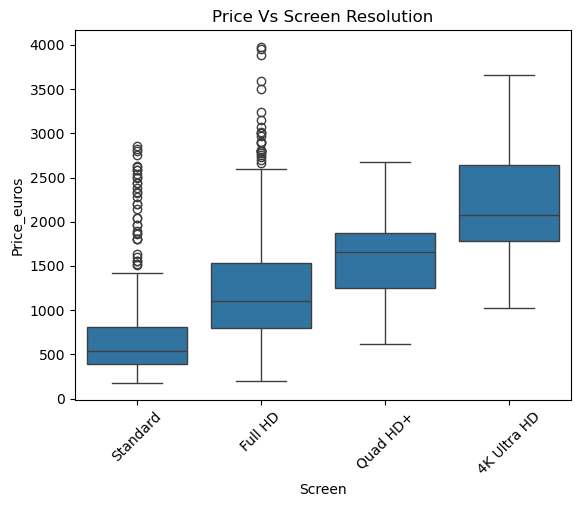

In [187]:
# Investigate Price vs Screen Resolution
#plt.figure(figsize=(15, 6))

sns.boxplot(x='Screen', y='Price_euros', data=df)
plt.xticks(rotation=45)
plt.title("Price Vs Screen Resolution")
plt.show()

In [188]:
#Get summary for statistics for Prices grouped by Screen
boxplot_statistics('Screen')

                    Mean         Std     Min      25%  50% (Median)      75%     Max
Standard      730.325122  557.902938   174.0   387.00       540.000   805.99  2858.0
Full HD      1227.418441  602.012934   196.0   799.00      1101.495  1535.00  3975.0
Quad HD+     1616.955000  448.622413   615.0  1250.75      1655.320  1876.50  2680.0
4K Ultra HD  2194.196500  647.639560  1029.0  1786.50      2074.000  2641.50  3659.4


<Axes: xlabel='PrimaryStorageType', ylabel='PrimaryStorage'>

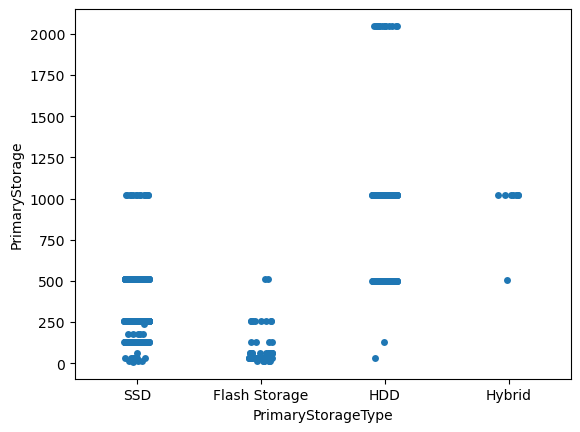

In [189]:
# Storage Distribution
sns.stripplot(x='PrimaryStorageType', y='PrimaryStorage', data = df)

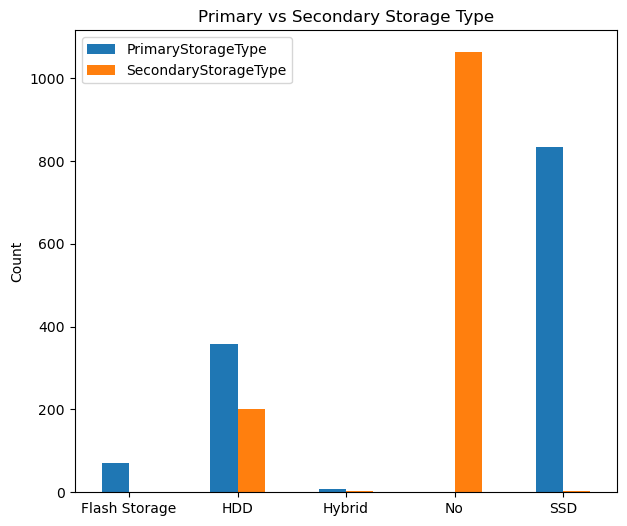

In [190]:
# Compare Primary vs Secondary Storage
storageTypeCompare = pd.DataFrame({
    'PrimaryStorageType': df['PrimaryStorageType'].value_counts(),
    'SecondaryStorageType': df['SecondaryStorageType'].value_counts()
})

# Plot the side-by-side bar chart
storageTypeCompare.plot(kind='bar', figsize=(7, 6))

# Set labels and title
plt.ylabel("Count")
plt.title('Primary vs Secondary Storage Type')
plt.xticks(rotation=0)

# Show the plot
plt.show()

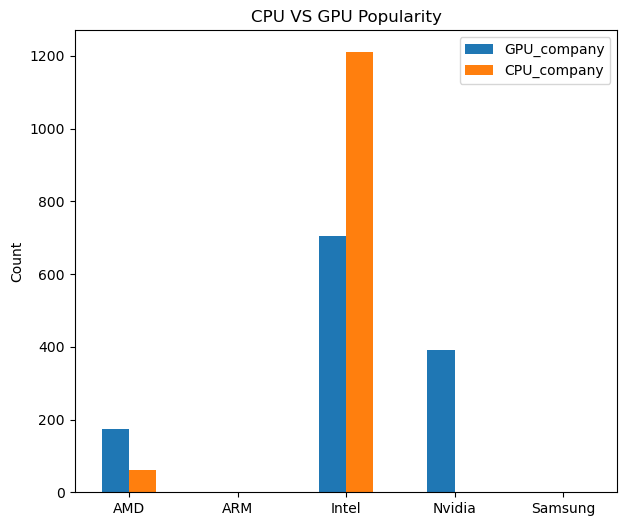

In [191]:
# CPU vs GPU
df[["GPU_company","CPU_company"]]

processingUnits = pd.DataFrame({
    'GPU_company': df['GPU_company'].value_counts(),
    'CPU_company': df['CPU_company'].value_counts()
})

processingUnits.plot(kind='bar', figsize=(7, 6))

# Set labels and title
plt.ylabel("Count")
plt.xticks(rotation=0)
plt.title("CPU VS GPU Popularity")

# Show the plot
plt.show()

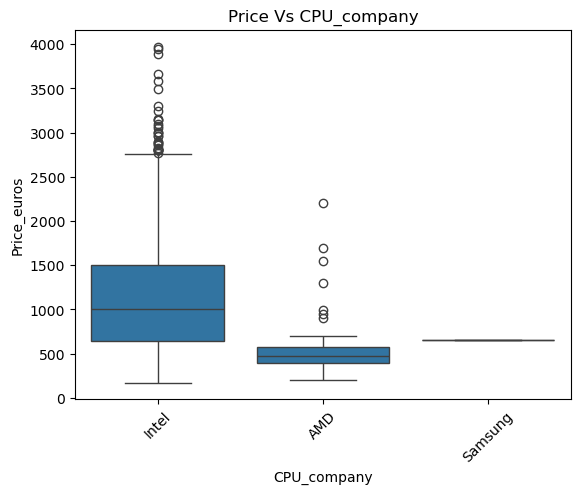

In [192]:
# Investigate Price vs cpu
#plt.figure(figsize=(15, 6))

sns.boxplot(x='CPU_company', y='Price_euros', data=df)
plt.xticks(rotation=45)
plt.title("Price Vs CPU_company")
plt.show()

In [193]:
#Get summary for statistics for Prices grouped by cpu
boxplot_statistics('CPU_company')

                Mean         Std    Min     25%  50% (Median)     75%     Max
Intel    1150.314810  661.876719  174.0  649.00      1010.255  1499.0  3975.0
AMD       560.993833  350.347274  199.0  397.25       469.000   576.0  2199.0
Samsung   659.000000         NaN  659.0  659.00       659.000   659.0   659.0


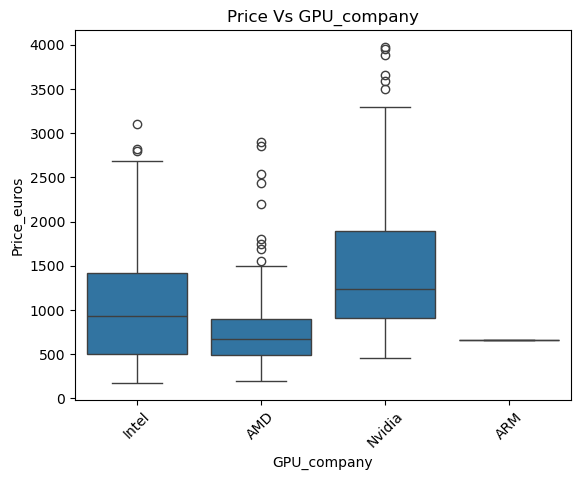

In [194]:
# Investigate Price vs GPU
#plt.figure(figsize=(15, 6))

sns.boxplot(x='GPU_company', y='Price_euros', data=df)
plt.xticks(rotation=45)
plt.title("Price Vs GPU_company")
plt.show()

In [195]:
#Get summary for statistics for Prices grouped by gpu
boxplot_statistics('GPU_company')

               Mean         Std    Min      25%  50% (Median)       75%     Max
Intel   1020.367713  589.601012  174.0  506.750         928.0  1420.915  3100.0
AMD      778.026552  440.323268  199.0  489.000         669.0   899.000  2899.0
Nvidia  1458.737398  726.729605  459.0  904.965        1239.0  1899.000  3975.0
ARM      659.000000         NaN  659.0  659.000         659.0   659.000   659.0


## PCPartsPicker¶


### Headphones

In [197]:
dfHeadphonesNoNullCategorical

,brand,model,form_factor,has_microphone,is_wireless,color
1,1MORE,Quad Driver,In Ear,True,False,Black / Red
2,1MORE,Triple Driver (Black/Gold),In Ear,True,False,Black / Gold
3,1MORE,Triple Driver (Silver),In Ear,True,False,Silver
4,1MORE,Triple Driver Lightning (Silver),In Ear,True,False,Silver
10,ADATA,EMIX H30 SE,Circumaural,True,False,Black / Red
...,...,...,...,...,...,...
2394,Yamaha,EPH-C500-BL,In Ear,False,False,Black / Silver
2396,Yamaha,HPH-200BL,Supra-aural,False,False,Black / Silver
2405,Yamaha,RH1C,Supra-aural,False,False,Black
2407,Yamaha,RH5MA,Supra-aural,False,False,Black


In [198]:
dfMouseNoNullNumeric['price']

0       52.852800
1       94.370562
2       74.163804
3       74.267622
8        7.540962
          ...    
2009    86.810724
2010    66.056562
2011    66.056562
2013    56.618562
2014    82.648566
Name: price, Length: 759, dtype: float64

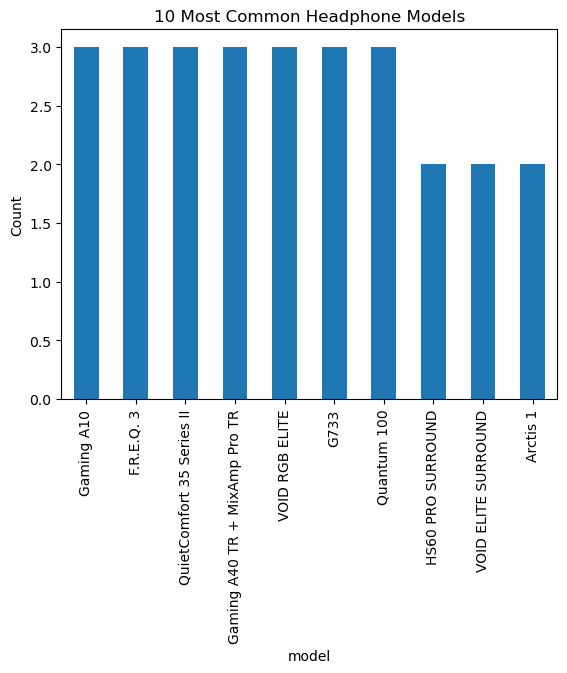

In [199]:
#model
dfHeadphonesNoNullCategorical['model'].value_counts()[:10].plot(kind='bar')
plt.ylabel("Count")
plt.title("10 Most Common Headphone Models")
plt.xticks(rotation=90)
plt.show()

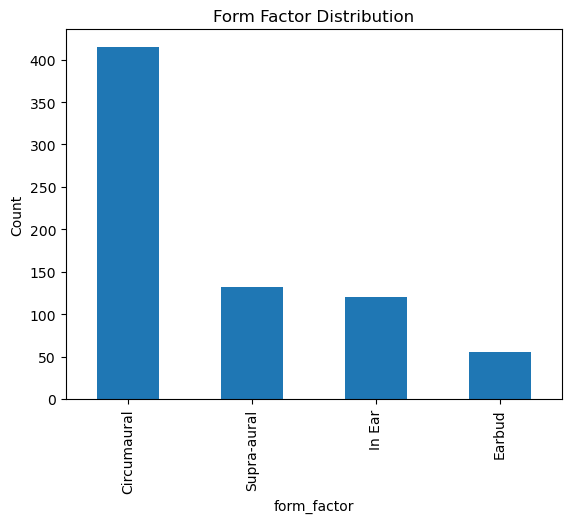

In [200]:
#form_factor
dfHeadphonesNoNullCategorical['form_factor'].value_counts().plot(kind='bar')
plt.ylabel("Count")
plt.xticks(rotation=90)
plt.title("Form Factor Distribution")
plt.show()

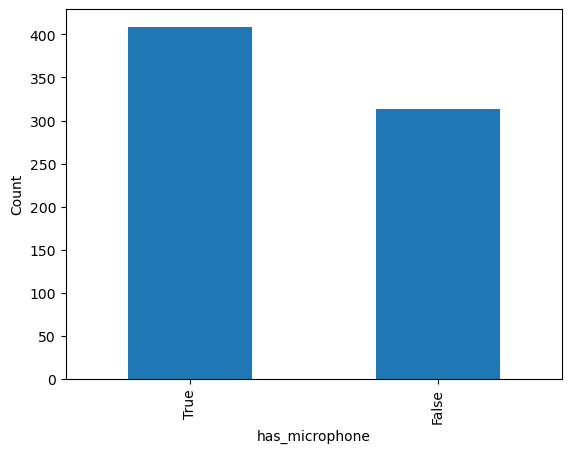

In [201]:
#has_microphone
dfHeadphonesNoNullCategorical['has_microphone'].value_counts().plot(kind='bar')
plt.ylabel("Count")
plt.xticks(rotation=90)
plt.show()

<Axes: xlabel='is_wireless'>

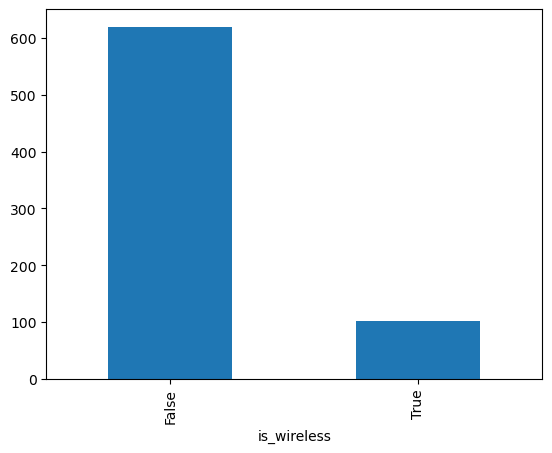

In [202]:
# Is Wireless
dfHeadphonesNoNullCategorical['is_wireless'].value_counts().plot(kind='bar')

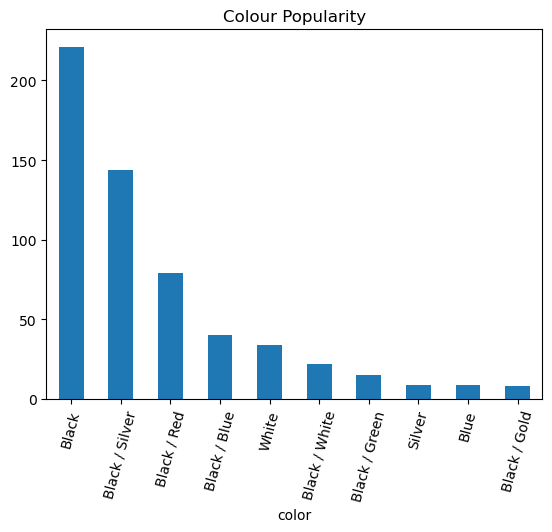

In [203]:
# Color
dfHeadphonesNoNullCategorical['color'].value_counts()[:10].plot(kind='bar')
plt.title("Colour Popularity")
plt.xticks(rotation=75)
plt.show()

[Text(0.5, 0, 'price (€)'), Text(0.5, 1.0, 'Price Distribution of Headphones')]

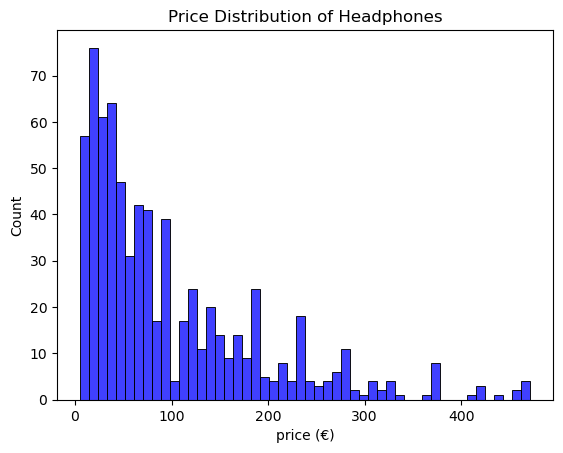

In [204]:
# Price Distribution
sns.histplot(dfHeadphonesNoNullNumeric['price'], bins=50, color='blue').set(xlabel='price (€)', title='Price Distribution of Headphones')

## Mouse

In [206]:
dfMouseNoNullCategorical

,brand,model,tracking,connection,max_dpi,hand_orientation,color
0,3M,EM500GPL,Optical,Wired,not available,Right,Black / Silver
1,3M,EM500GPS,Optical,Wired,not available,Right,Black
2,3M,EM550GPL,Optical,Wireless,not available,Right,Black
3,3M,EM550GPS,Optical,Wireless,not available,Right,Black
8,A4Tech,D-120,Optical,Wired,1000.0,Both,Black / Silver
...,...,...,...,...,...,...,...
2009,Zowie,FK2,Optical,Wired,3200.0,Both,Black / Yellow
2010,Zowie,S1,Optical,Wired,3200.0,Right,Black
2011,Zowie,S2,Optical,Wired,3200.0,Right,Black
2013,Zowie,ZA12,Optical,Wired,3200.0,Both,Black


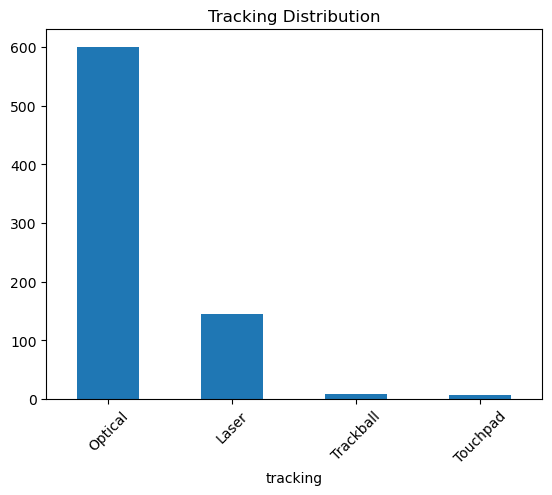

In [207]:
# Tracking
dfMouseNoNullCategorical['tracking'].value_counts().plot(kind='bar')
plt.xticks(rotation=45)
plt.title("Tracking Distribution")
plt.show()

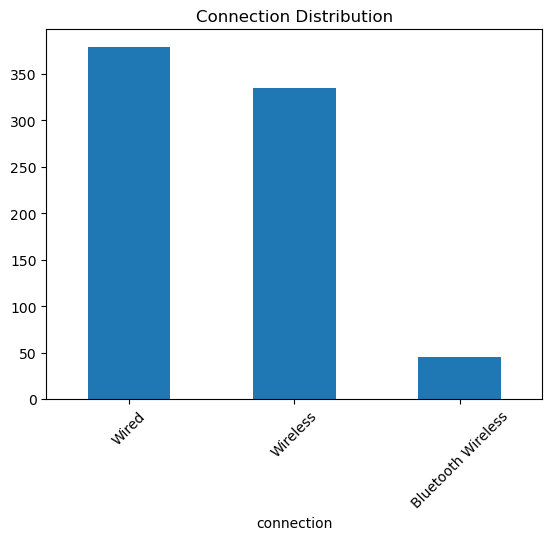

In [208]:
# Connection
dfMouseNoNullCategorical['connection'].value_counts().plot(kind='bar')
plt.title("Connection Distribution")
plt.xticks(rotation=45)
plt.show()

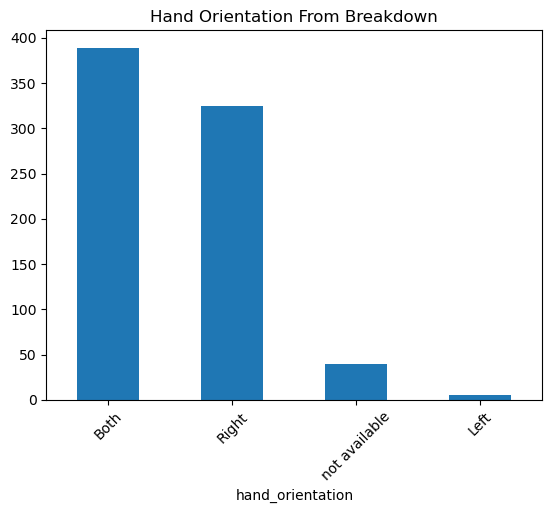

In [209]:
# hand_orientation
dfMouseNoNullCategorical['hand_orientation'].value_counts().plot(kind='bar')
plt.xticks(rotation=45)
plt.title("Hand Orientation From Breakdown")
plt.show()

<Axes: xlabel='color'>

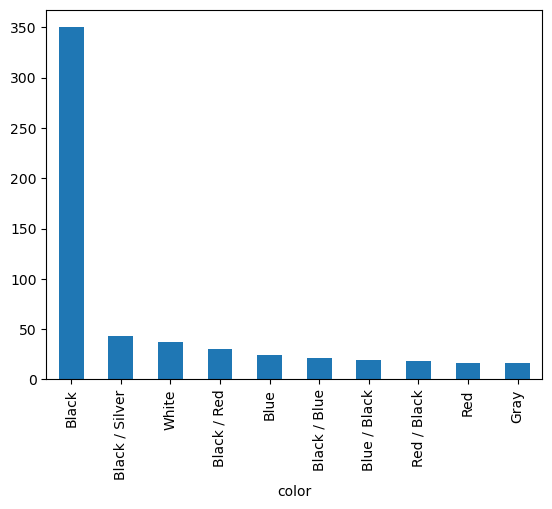

In [210]:
# color
dfMouseNoNullCategorical['color'].value_counts()[:10].plot(kind='bar')

[Text(0.5, 0, 'price'), Text(0.5, 1.0, 'Price Distribution of Mice')]

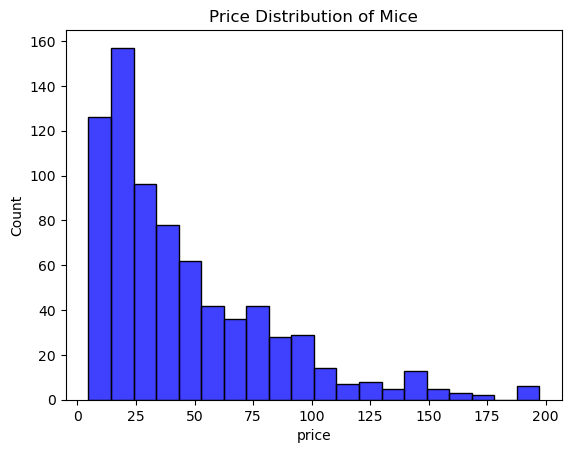

In [211]:
# Price Distribution
sns.histplot(dfMouseNoNullNumeric['price'], bins=20, color='blue').set(xlabel='price', title='Price Distribution of Mice')

## Keyboards

[Text(0.5, 0, 'price'), Text(0.5, 1.0, 'Price Distribution of Keyboards')]

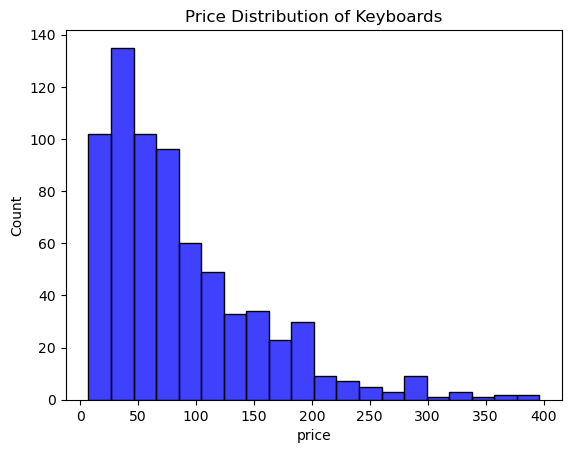

In [213]:
# Price Distribution
sns.histplot(dfKeyboardNoNullNumeric['price'], bins=20, color='blue').set(xlabel='price', title='Price Distribution of Keyboards')

In [214]:
dfKeyboardNoNullCategorical

,brand,model,style,switches,backlight,tenkeyless,connection,color
2,A4Tech,7300N,Ergonomic,not available,not available,True,Wireless,Gray / Black
5,A4Tech,9500H,Standard,not available,not available,False,Wireless,Black
7,A4Tech,B120,Gaming,not available,Red,False,Wired,Black
9,A4Tech,G800V,Gaming,not available,not available,False,Wired,Black
11,A4Tech,KD-126,Standard,not available,Blue,False,Wired,Black
...,...,...,...,...,...,...,...,...
2317,i-rocks,RF-6577L-WH,Slim,not available,not available,False,Wireless,White
2327,matias,FK318PCLBB,Standard,not available,Multicolor,False,Wired,Black
2336,matias,Laptop Pro for Mac,Mini,ALPS White,not available,True,Wired,Black / Silver
2337,matias,Mini Quiet Pro for PC,Mini,ALPS White,not available,True,Wired,Black


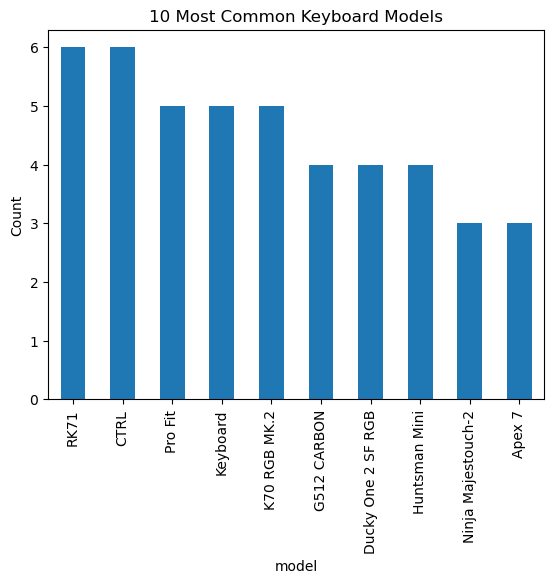

In [215]:
#model
dfKeyboardNoNullCategorical['model'].value_counts()[:10].plot(kind='bar')
plt.ylabel("Count")
plt.title("10 Most Common Keyboard Models")
plt.xticks(rotation=90)
plt.show()

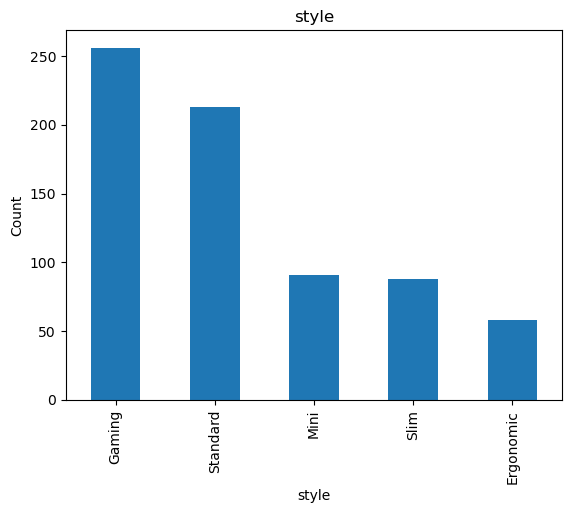

In [216]:
#style
dfKeyboardNoNullCategorical['style'].value_counts().plot(kind='bar')
plt.ylabel("Count")
plt.title("style")
plt.xticks(rotation=90)
plt.show()

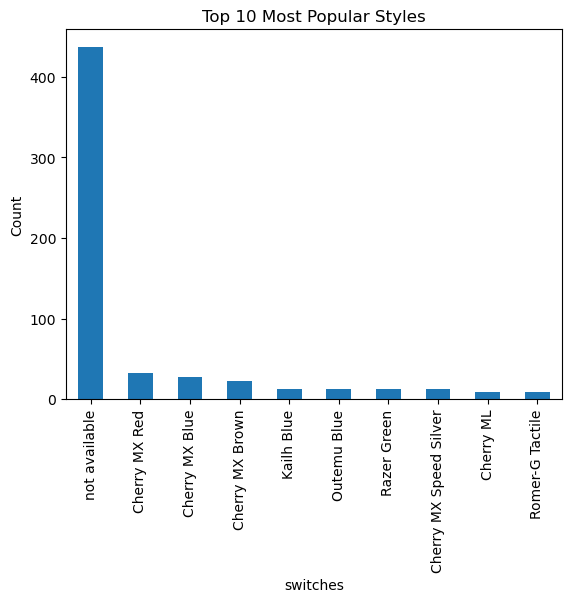

In [217]:
#switches
dfKeyboardNoNullCategorical['switches'].value_counts()[:10].plot(kind='bar')
plt.ylabel("Count")
plt.title("Top 10 Most Popular Styles")
plt.xticks(rotation=90)
plt.show()

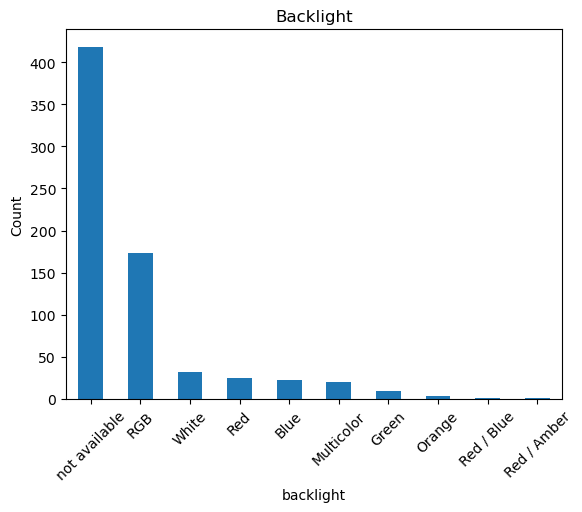

In [218]:
#backlight
dfKeyboardNoNullCategorical['backlight'].value_counts().plot(kind='bar')
plt.ylabel("Count")
plt.title("Backlight")
plt.xticks(rotation=45)
plt.show()

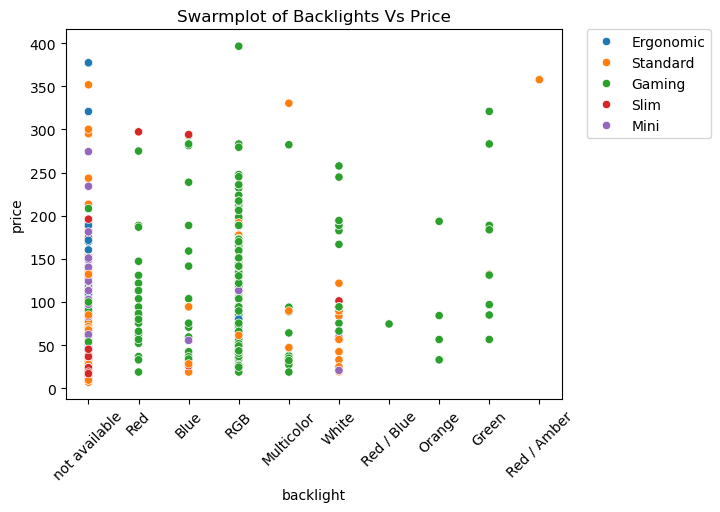

In [219]:
# Compare Price with Style and Blacklight features
sns.scatterplot(x='backlight', y='price', data=dfKeyboardNoNull, hue='style')
plt.title("Swarmplot of Backlights Vs Price")
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left', borderaxespad=0)
plt.xticks(rotation=45)
plt.show()

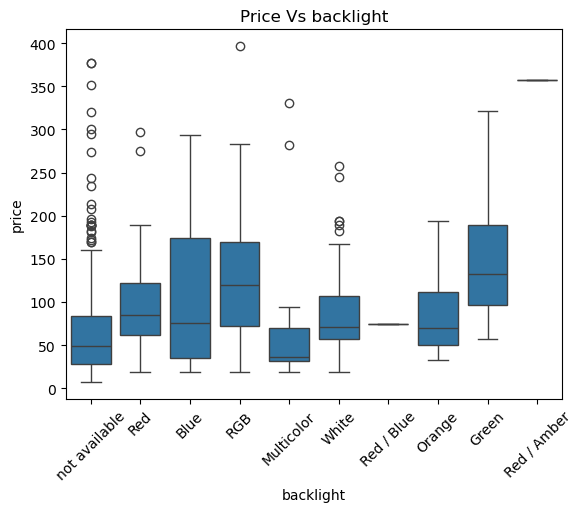

In [220]:
# Investigate Price vs blacklight
#plt.figure(figsize=(15, 6))

sns.boxplot(x='backlight', y='price', data=dfKeyboardNoNull)
plt.xticks(rotation=45)
plt.title("Price Vs backlight")
plt.show()

In [221]:
#Get summary for statistics for Prices
get_continuous_details(dfKeyboardNoNull[["price"]])

,count,mean,std,min,25%,50%,75%,max,Unique
price,706.0,86.937709,67.860762,7.069062,36.145181,66.047124,121.7502,396.386562,412


In [222]:
#provides the statistics from the boxplot analysis of backlight

stats = {}

#get statistics grouped by feature
for i in list(dfKeyboardNoNull["backlight"].unique()):
    groupPrices = dfKeyboardNoNull[dfKeyboardNoNull["backlight"] == i]["price"]
    stats[i] = {
            'Mean': groupPrices.mean(),
            'Std': groupPrices.std(),
            'Min': groupPrices.min(),
            '25%': groupPrices.quantile(0.25),
            '50% (Median)': groupPrices.median(),
            '75%': groupPrices.quantile(0.75),
            'Max': groupPrices.max(),
    }
statsDf = pd.DataFrame(stats).T
print(statsDf.to_string())

                     Mean        Std         Min         25%  50% (Median)         75%         Max
not available   67.284766  57.175684    7.069062   28.314000     49.025691   83.759890  377.246298
Red            103.264933  70.492050   18.857124   61.328124     84.932562  121.740762  297.174306
Blue           116.523189  97.937928   18.857124   35.321715     75.485124  173.895150  294.040890
RGB            122.874577  62.047811   18.866562   72.653724    119.862600  169.874562  396.386562
Multicolor      71.533905  83.567110   18.857124   31.872126     36.326862   70.303662  330.320562
White           94.550474  65.598309   19.272396   56.618562     70.869942  106.411091  257.657400
Red / Blue      74.560200        NaN   74.560200   74.560200     74.560200   74.560200   74.560200
Orange          91.827021  70.926287   33.023562   50.656105     70.407480  111.578395  193.469562
Green          164.252660  89.564258   56.618562   96.956574    132.122562  188.750562  320.882562
Red / Ambe

# 6. Insights
This section is a repeat of the graphs featured in section 5, but arranged in the order in which they appear in section 6 of the report

### 1 Ram Has A Strong Correlation with Price

In [225]:
# Calculate Correlation Coefficients
dfSplit['numeric'].corr()

,Inches,Ram,Weight,Price_euros,ScreenW,ScreenH,CPU_freq,PrimaryStorage,SecondaryStorage,StorageSSD,StorageFlash,StorageHDD,StorageHybrid,TotalStorage
Inches,1.000000,0.233007,0.825587,0.045055,-0.081130,-0.106073,0.301796,0.263559,0.392107,-0.114164,-0.227095,0.533729,0.052843,0.538102
Ram,0.233007,1.000000,0.381257,0.725986,0.398831,0.390415,0.360962,0.003878,0.406921,0.586634,-0.056120,0.112201,0.052954,0.354238
Weight,0.825587,0.381257,1.000000,0.192778,-0.045230,-0.066717,0.314721,0.173315,0.486066,-0.070062,-0.177255,0.518342,0.106214,0.550878
Price_euros,0.045055,0.725986,0.192778,1.000000,0.533934,0.530885,0.430805,-0.147986,0.316963,0.664711,-0.036372,-0.086961,0.025696,0.161571
ScreenW,-0.081130,0.398831,-0.045230,0.533934,1.000000,0.993865,0.169959,-0.085080,0.153038,0.504475,-0.011860,-0.113545,-0.000796,0.067691
ScreenH,-0.106073,0.390415,-0.066717,0.530885,0.993865,1.000000,0.155561,-0.092015,0.141632,0.495598,0.021937,-0.125866,-0.002404,0.052592
CPU_freq,0.301796,0.360962,0.314721,0.430805,0.169959,0.155561,1.000000,0.053430,0.226897,0.257661,-0.222956,0.129852,0.049531,0.236346
PrimaryStorage,0.263559,0.003878,0.173315,-0.147986,-0.085080,-0.092015,0.053430,1.000000,-0.243815,-0.213649,-0.094474,0.560832,0.100781,0.546800
SecondaryStorage,0.392107,0.406921,0.486066,0.316963,0.153038,0.141632,0.226897,-0.243815,1.000000,0.106153,-0.058755,0.582401,0.008247,0.678678
StorageSSD,-0.114164,0.586634,-0.070062,0.664711,0.504475,0.495598,0.257661,-0.213649,0.106153,1.000000,-0.147862,-0.395954,-0.049351,-0.070151


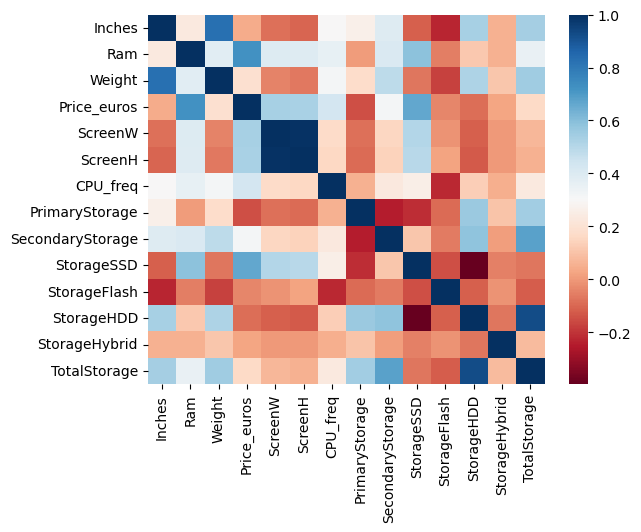

In [226]:
# Compute Correlation Coefficient
sns.heatmap(dfSplit['numeric'].corr(), cmap="RdBu");

In [227]:
#Check the Price Correlation
dfSplit['numeric'].corr().loc["Price_euros",]

Inches              0.045055
Ram                 0.725986
Weight              0.192778
Price_euros         1.000000
ScreenW             0.533934
ScreenH             0.530885
CPU_freq            0.430805
PrimaryStorage     -0.147986
SecondaryStorage    0.316963
StorageSSD          0.664711
StorageFlash       -0.036372
StorageHDD         -0.086961
StorageHybrid       0.025696
TotalStorage        0.161571
Name: Price_euros, dtype: float64

### 2 Popularity of Windows

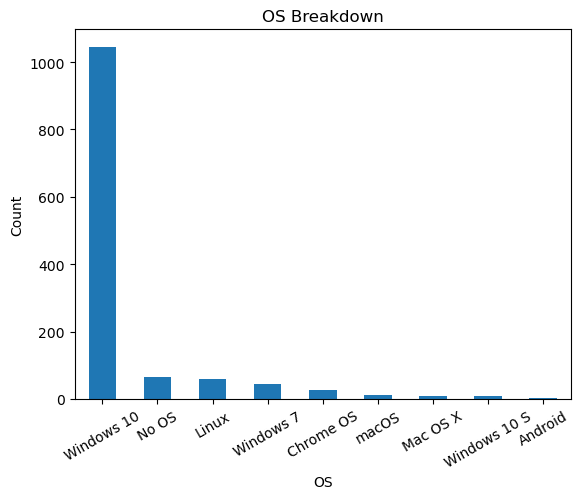

In [229]:
#'OS Count'
df['OS'].value_counts().plot(kind='bar')
plt.ylabel("Count")
plt.title('OS Breakdown')
plt.xticks(rotation=30)
plt.show()

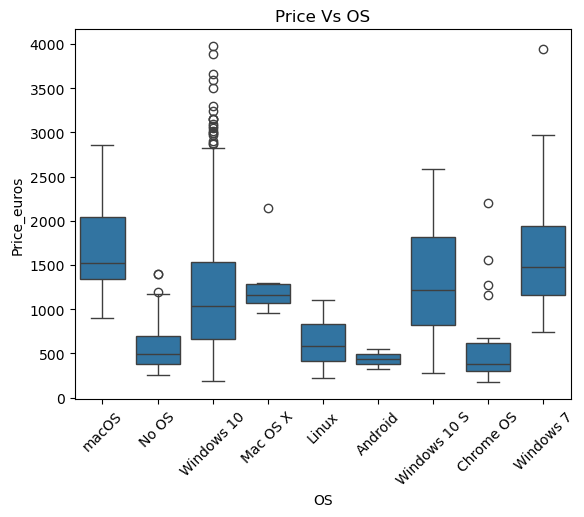

In [230]:
# Investigate Price vs OS
#plt.figure(figsize=(15, 6))

sns.boxplot(x='OS', y='Price_euros', data=df)
plt.xticks(rotation=45)
plt.title("Price Vs OS")
plt.show()

In [231]:
#Show % breakdown
(df['OS'].value_counts()/df['OS'].shape[0]) * 100

OS
Windows 10      82.218725
No OS            5.192762
Linux            4.563336
Windows 7        3.461841
Chrome OS        2.124312
macOS            1.022817
Mac OS X         0.629426
Windows 10 S     0.629426
Android          0.157356
Name: count, dtype: float64

In [232]:
#Get summary for statistics for Prices
get_continuous_details(dfNumeric[["Price_euros"]])

,count,mean,std,min,25%,50%,75%,max,Unique
Price_euros,1271.0,1122.108222,662.225815,174.0,606.0,985.0,1491.4,3975.0,787


In [233]:
#Get summary for statistics for Prices
get_continuous_details(dfNumeric[["Price_euros"]])

,count,mean,std,min,25%,50%,75%,max,Unique
Price_euros,1271.0,1122.108222,662.225815,174.0,606.0,985.0,1491.4,3975.0,787


In [234]:
#Get summary for statistics for Prices grouped by OS
boxplot_statistics('OS')

                     Mean         Std     Min       25%  50% (Median)        75%      Max
macOS         1749.630769  588.443390  898.94  1339.690       1518.55  2040.0000  2858.00
No OS          587.973333  277.151691  252.36   375.225        499.00   694.7500  1399.95
Windows 10    1168.286986  658.031020  191.90   659.000       1039.00  1534.0000  3975.00
Mac OS X      1262.871250  374.135623  959.00  1073.750       1164.00  1284.2500  2139.97
Linux          621.867069  251.586973  224.00   412.750        579.26   835.9975  1099.00
Android        434.000000  162.634560  319.00   376.500        434.00   491.5000   549.00
Windows 10 S  1286.480000  787.442491  277.99   826.750       1214.50  1816.2125  2589.00
Chrome OS      553.585185  470.057049  174.00   296.000        375.00   615.0000  2199.00
Windows 7     1625.234318  667.644290  737.00  1159.015       1482.00  1936.8450  3949.40


### 3 Intel Is the Leading Producer of CPUs

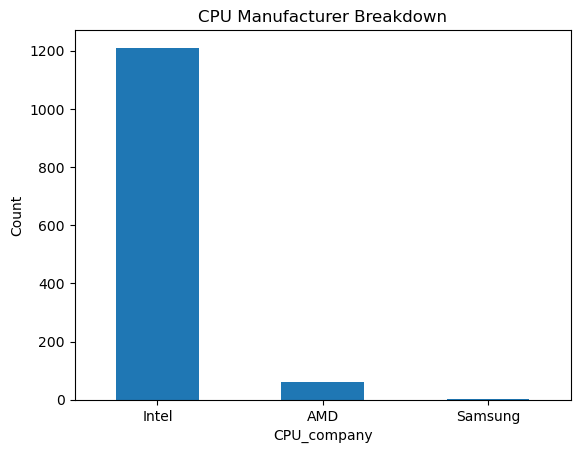

In [236]:
#CPU_company
df['CPU_company'].value_counts().plot(kind='bar')
plt.ylabel("Count")
plt.title('CPU Manufacturer Breakdown')
plt.xticks(rotation=0)
plt.show()

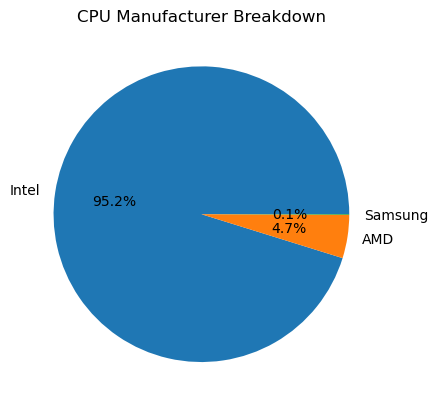

In [237]:
#'OS'
df['CPU_company'].value_counts().plot(kind='pie', autopct='%1.1f%%')
plt.ylabel("")
plt.title('CPU Manufacturer Breakdown')
plt.show()

In [238]:
#Show % breakdown
(df['CPU_company'].value_counts()/df['OS'].shape[0]) * 100

CPU_company
Intel      95.200629
AMD         4.720692
Samsung     0.078678
Name: count, dtype: float64

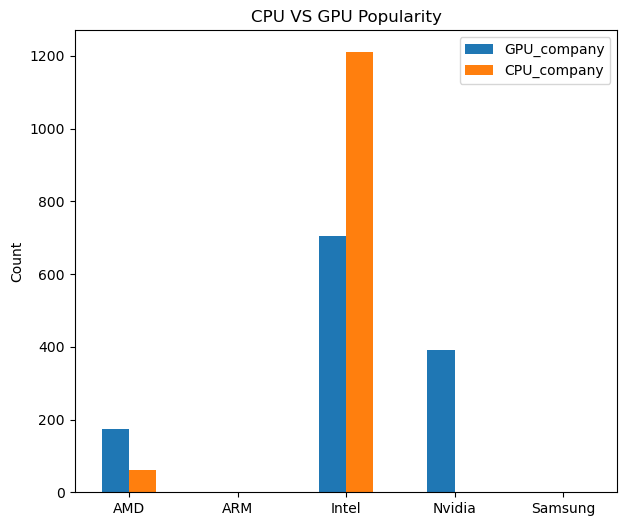

In [239]:
# CPU vs GPU
df[["GPU_company","CPU_company"]]

processingUnits = pd.DataFrame({
    'GPU_company': df['GPU_company'].value_counts(),
    'CPU_company': df['CPU_company'].value_counts()
})

processingUnits.plot(kind='bar', figsize=(7, 6))

# Set labels and title
plt.ylabel("Count")
plt.xticks(rotation=0)
plt.title("CPU VS GPU Popularity")

# Show the plot
plt.show()

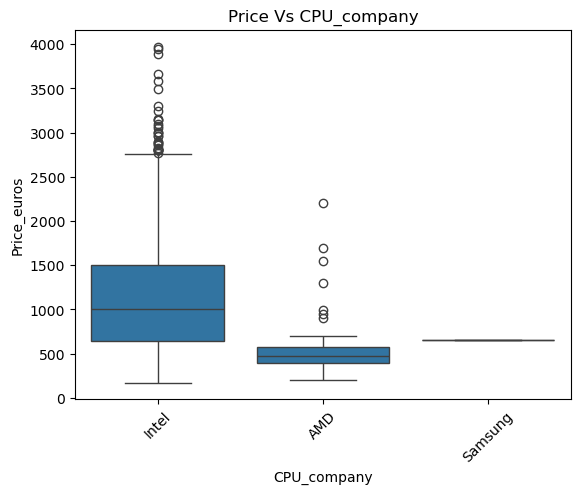

In [240]:
# Investigate Price vs cpu
#plt.figure(figsize=(15, 6))

sns.boxplot(x='CPU_company', y='Price_euros', data=df)
plt.xticks(rotation=45)
plt.title("Price Vs CPU_company")
plt.show()

In [241]:
#Get summary for statistics for Prices grouped by cpu
boxplot_statistics('CPU_company')

                Mean         Std    Min     25%  50% (Median)     75%     Max
Intel    1150.314810  661.876719  174.0  649.00      1010.255  1499.0  3975.0
AMD       560.993833  350.347274  199.0  397.25       469.000   576.0  2199.0
Samsung   659.000000         NaN  659.0  659.00       659.000   659.0   659.0


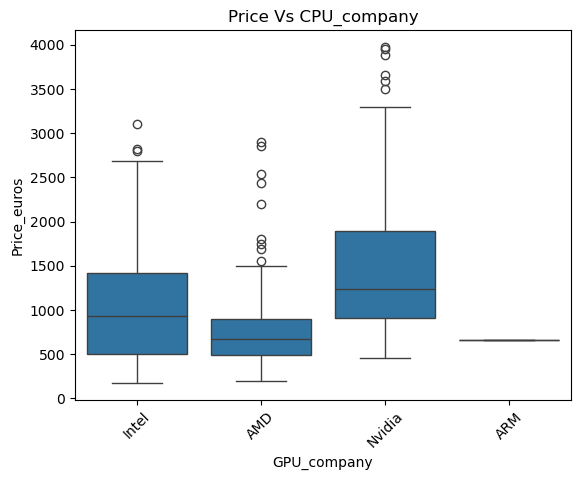

In [242]:
# Investigate Price vs GPU
#plt.figure(figsize=(15, 6))

sns.boxplot(x='GPU_company', y='Price_euros', data=df)
plt.xticks(rotation=45)
plt.title("Price Vs CPU_company")
plt.show()

In [243]:
#Get summary for statistics for Prices grouped by gpu
boxplot_statistics('GPU_company')

               Mean         Std    Min      25%  50% (Median)       75%     Max
Intel   1020.367713  589.601012  174.0  506.750         928.0  1420.915  3100.0
AMD      778.026552  440.323268  199.0  489.000         669.0   899.000  2899.0
Nvidia  1458.737398  726.729605  459.0  904.965        1239.0  1899.000  3975.0
ARM      659.000000         NaN  659.0  659.000         659.0   659.000   659.0


### 4. Clustering of HDD, SSD, and Flash Storage

<Axes: xlabel='PrimaryStorage', ylabel='Price_euros'>

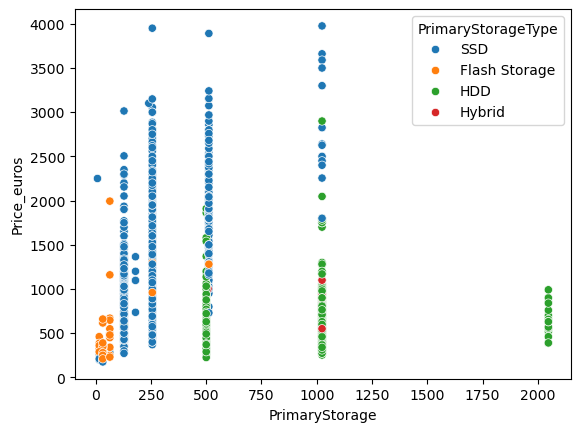

In [245]:
# Storage Distribution (Boxplot)
sns.scatterplot(x='PrimaryStorage', y='Price_euros', data=df, hue='PrimaryStorageType')

### 5. FullHD is More Popular Than Standard Definition

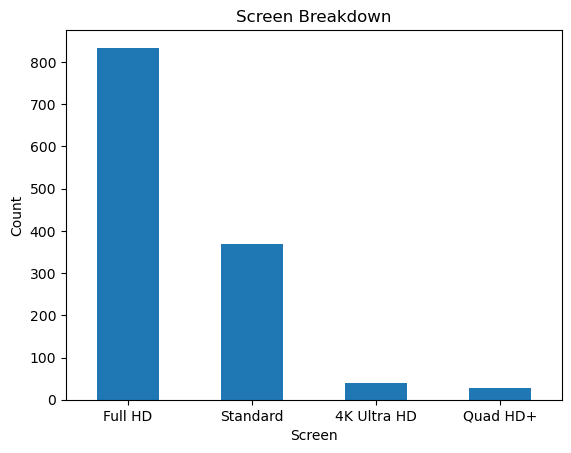

In [247]:
# Screen
df['Screen'].value_counts().plot(kind='bar')
plt.ylabel("Count")
plt.title('Screen Breakdown')
plt.xticks(rotation=0)
plt.show()

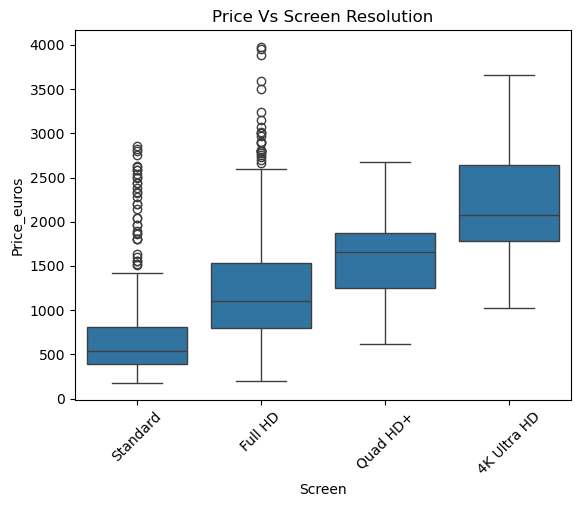

In [248]:
# Investigate Price vs Screen Resolution
#plt.figure(figsize=(15, 6))

sns.boxplot(x='Screen', y='Price_euros', data=df)
plt.xticks(rotation=45)
plt.title("Price Vs Screen Resolution")
plt.show()

In [249]:
#Get summary for statistics for Prices grouped by Screen
boxplot_statistics('Screen')

                    Mean         Std     Min      25%  50% (Median)      75%     Max
Standard      730.325122  557.902938   174.0   387.00       540.000   805.99  2858.0
Full HD      1227.418441  602.012934   196.0   799.00      1101.495  1535.00  3975.0
Quad HD+     1616.955000  448.622413   615.0  1250.75      1655.320  1876.50  2680.0
4K Ultra HD  2194.196500  647.639560  1029.0  1786.50      2074.000  2641.50  3659.4


### 6. Workstation, Ultrabook and Gaming PCs are, on average, more expensive than other computers.

<Axes: xlabel='PrimaryStorage', ylabel='Price_euros'>

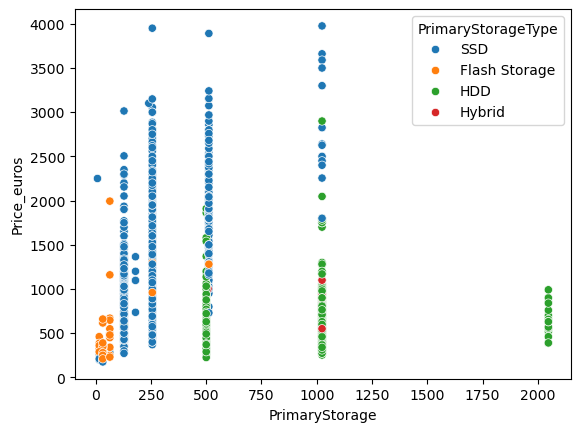

In [251]:
# Storage Distribution (Boxplot)
sns.scatterplot(x='PrimaryStorage', y='Price_euros', data=df, hue='PrimaryStorageType')

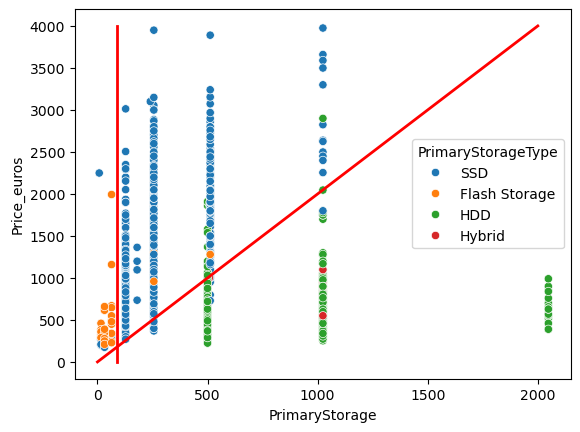

In [252]:
#Add red classification line, approximatly where x=2y
sns.scatterplot(x='PrimaryStorage', y='Price_euros', data=df, hue='PrimaryStorageType')
plt.plot([0, 2000], [0, 4000], color='red', linestyle='-', linewidth=2)
plt.plot([90, 90], [0, 4000], color='red', linestyle='-', linewidth=2)
plt.show()

In [253]:
# Get missclassification Rating
dfClassification = df.loc[ df['PrimaryStorageType'] != "Hybrid",['PrimaryStorageType','PrimaryStorage','Price_euros']]
dfClassification["prediction"] = "None"
dfClassification.loc[(dfClassification['Price_euros']*2) > (dfClassification['PrimaryStorage'].astype(int)), ["prediction"]] = 'SSD'
dfClassification.loc[dfClassification["prediction"] == "None", ["prediction"]] = 'HDD'
dfClassification.loc[(dfClassification['PrimaryStorage'].astype(int)) < 80, ["prediction"]] = 'Flash Storage'

In [254]:
#Confusion Matrix
classificationMatrix = dfClassification.groupby(['PrimaryStorageType', 'prediction']).size()
classificationMatrix

PrimaryStorageType  prediction   
Flash Storage       Flash Storage     57
                    SSD               14
HDD                 Flash Storage      1
                    HDD               90
                    SSD              268
SSD                 Flash Storage     11
                    SSD              822
dtype: int64

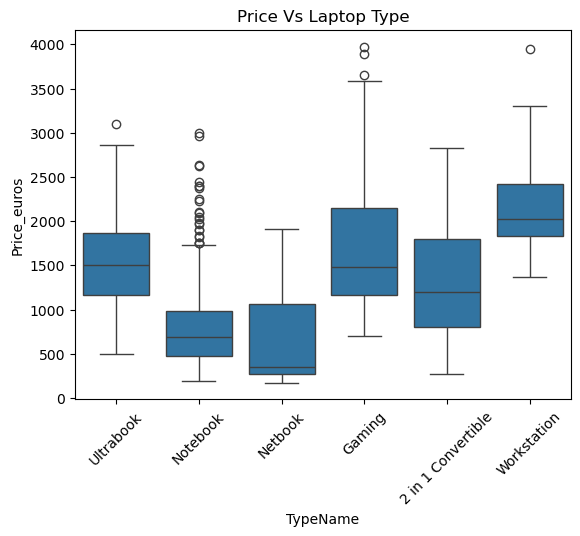

In [255]:
# Investigate Price vs Laptop Type
#plt.figure(figsize=(15, 6))

sns.boxplot(x='TypeName', y='Price_euros', data=df)
plt.title("Price Vs Laptop Type")
plt.xticks(rotation=45)
plt.show()

In [256]:
#Get summary for statistics for Prices grouped by TypeName
boxplot_statistics('TypeName')

                           Mean         Std     Min        25%  50% (Median)       75%     Max
Ultrabook           1556.676031  484.737332   499.0  1159.7750      1499.000  1869.000  3100.0
Notebook             782.922890  419.448877   196.0   478.9175       694.495   979.750  2999.0
Netbook              673.382609  592.093391   174.0   269.0000       355.000  1066.500  1908.0
Gaming              1691.305567  709.310241   699.0  1168.5000      1486.770  2151.685  3975.0
2 in 1 Convertible  1289.714530  617.436633   275.0   798.0100      1199.000  1799.000  2824.0
Workstation         2205.050357  596.748493  1369.0  1835.7500      2028.950  2425.500  3949.4


### 7. All 4 Datasets Had a Price Feature with a Positive Skew and Multiple Outliers

[Text(0.5, 0, 'price (€)'), Text(0.5, 1.0, 'Price Distribution of Laptops')]

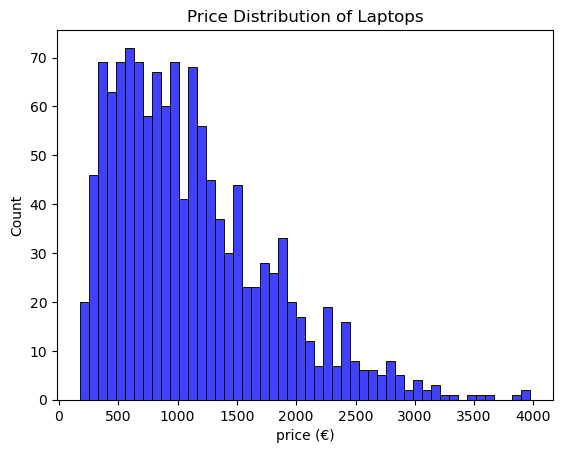

In [258]:
# Price Distribution of Laptops
sns.histplot(df['Price_euros'], bins=50, color='blue').set(xlabel='price (€)', title='Price Distribution of Laptops')

[Text(0.5, 0, 'price (€)'), Text(0.5, 1.0, 'Price Distribution of Headphones')]

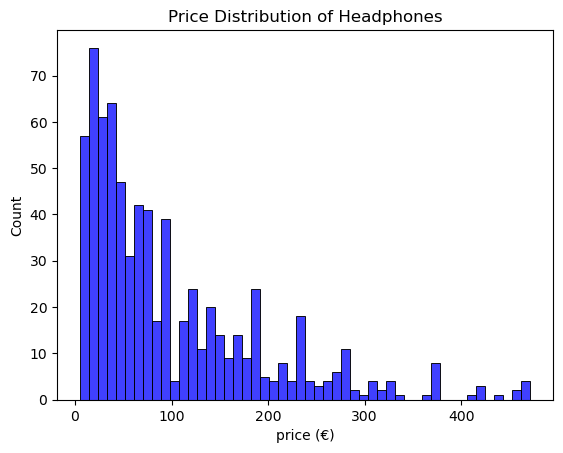

In [259]:
# Price Distribution of Headphones
sns.histplot(dfHeadphonesNoNull['price'], bins=50, color='blue').set(xlabel='price (€)', title='Price Distribution of Headphones')

[Text(0.5, 0, 'price (€)'), Text(0.5, 1.0, 'Price Distribution of Mice')]

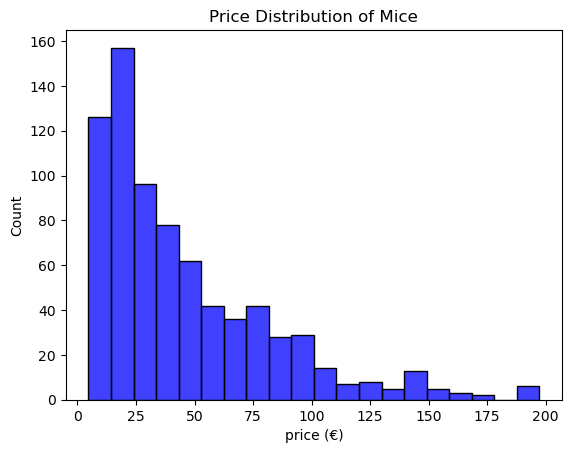

In [260]:
# Price Distribution of Mice
sns.histplot(dfMouseNoNullNumeric['price'], bins=20, color='blue').set(xlabel='price (€)', title='Price Distribution of Mice')

[Text(0.5, 0, 'price (€)'), Text(0.5, 1.0, 'Price Distribution of Keyboards')]

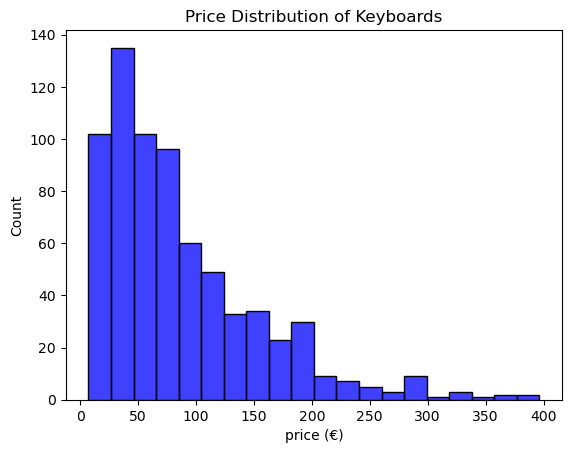

In [261]:
# Price Distribution
sns.histplot(dfKeyboardNoNullNumeric['price'], bins=20, color='blue').set(xlabel='price (€)', title='Price Distribution of Keyboards')

### 8. The Vast Majority of Gaming Keyboards Had Built-In Lighting 

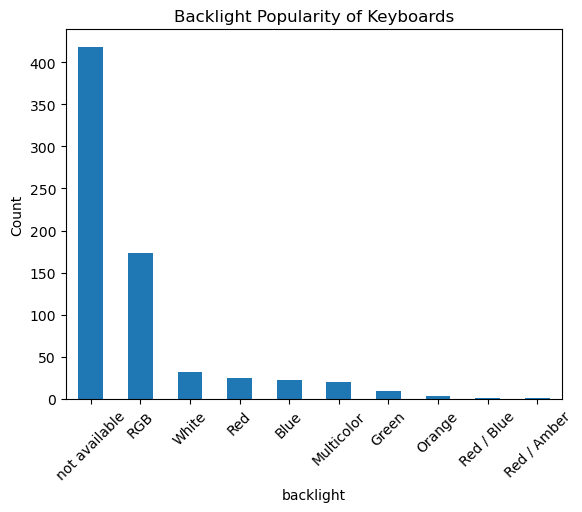

In [264]:
#backlight
dfKeyboardNoNullCategorical['backlight'].value_counts().plot(kind='bar')
plt.ylabel("Count")
plt.title("Backlight Popularity of Keyboards")
plt.xticks(rotation=45)
plt.show()

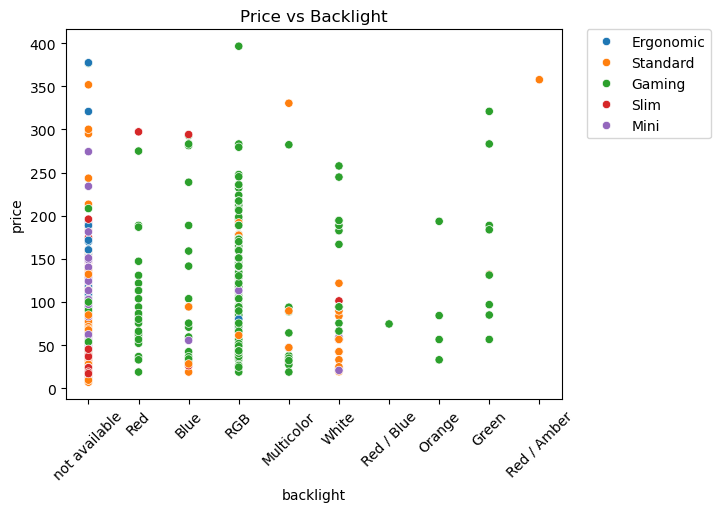

In [265]:
# Compare Price with Style and Blacklight features
sns.scatterplot(x='backlight', y='price', data=dfKeyboardNoNull, hue='style')
plt.xticks(rotation=45)
plt.title("Price vs Backlight")
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left', borderaxespad=0)
plt.show()

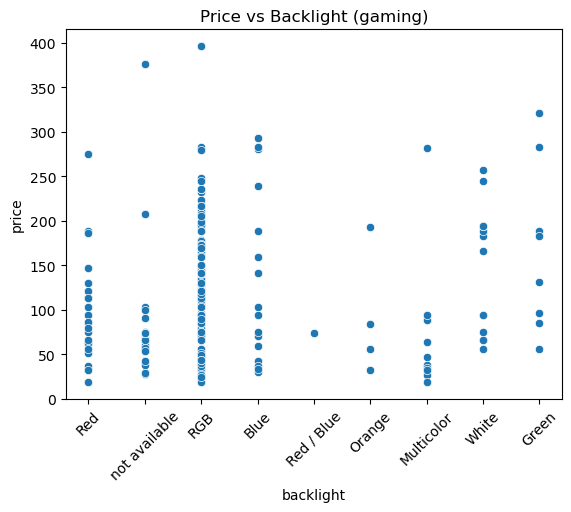

In [266]:
sns.scatterplot(x='backlight', y='price', data=dfKeyboardNoNull[dfKeyboardNoNull["style"] == "Gaming"])
plt.xticks(rotation=45)
plt.title("Price vs Backlight (gaming)")
plt.show()

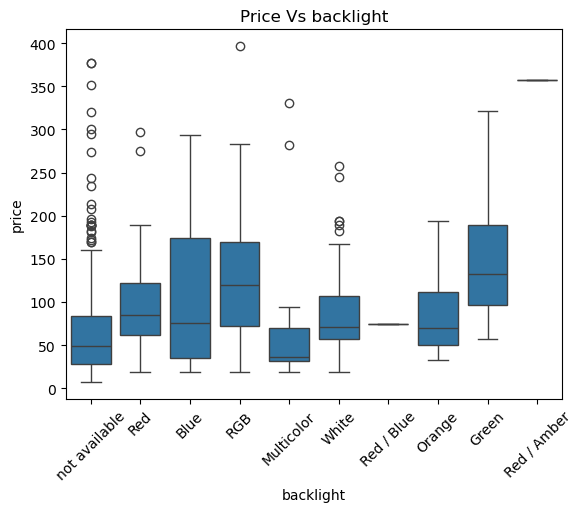

In [267]:
# Investigate Price vs blacklight
#plt.figure(figsize=(15, 6))

sns.boxplot(x='backlight', y='price', data=dfKeyboardNoNull)
plt.xticks(rotation=45)
plt.title("Price Vs backlight")
plt.show()

In [268]:
#Get summary for statistics for Prices
get_continuous_details(dfKeyboardNoNull[["price"]])

,count,mean,std,min,25%,50%,75%,max,Unique
price,706.0,86.937709,67.860762,7.069062,36.145181,66.047124,121.7502,396.386562,412


In [269]:
#provides the statistics from the boxplot analysis of backlight

stats = {}

#get statistics grouped by feature
for i in list(dfKeyboardNoNull["backlight"].unique()):
    groupPrices = dfKeyboardNoNull[dfKeyboardNoNull["backlight"] == i]["price"]
    stats[i] = {
            'Mean': groupPrices.mean(),
            'Std': groupPrices.std(),
            'Min': groupPrices.min(),
            '25%': groupPrices.quantile(0.25),
            '50% (Median)': groupPrices.median(),
            '75%': groupPrices.quantile(0.75),
            'Max': groupPrices.max(),
    }
statsDf = pd.DataFrame(stats).T
print(statsDf.to_string())

                     Mean        Std         Min         25%  50% (Median)         75%         Max
not available   67.284766  57.175684    7.069062   28.314000     49.025691   83.759890  377.246298
Red            103.264933  70.492050   18.857124   61.328124     84.932562  121.740762  297.174306
Blue           116.523189  97.937928   18.857124   35.321715     75.485124  173.895150  294.040890
RGB            122.874577  62.047811   18.866562   72.653724    119.862600  169.874562  396.386562
Multicolor      71.533905  83.567110   18.857124   31.872126     36.326862   70.303662  330.320562
White           94.550474  65.598309   19.272396   56.618562     70.869942  106.411091  257.657400
Red / Blue      74.560200        NaN   74.560200   74.560200     74.560200   74.560200   74.560200
Orange          91.827021  70.926287   33.023562   50.656105     70.407480  111.578395  193.469562
Green          164.252660  89.564258   56.618562   96.956574    132.122562  188.750562  320.882562
Red / Ambe

# 7. Machine Learning

See final project Write-up

# 8. Conclusion
See final project Write-up